#Classificador de Competências do Pensamento Computacional

Este colab implementa um classificador automático que identifica competências do Pensamento Computacional em questões-problema do POSCOMP. O código tem como base o classificador de áreas do conhecimento em questões do POSCOMP, acessível [neste link](https://colab.research.google.com/drive/14tks2YRWvHw1Qo-qrFUr3oc_j_qUFo6A?usp=sharing#scrollTo=K53Sewpetw_r).

## Instalação de dependências

In [1]:
!pip install openai
!pip install pandas
!pip install tqdm

In [2]:
import os
from openai import OpenAI
import pandas as pd
import json
from tqdm import tqdm
from datetime import datetime
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, f1_score, accuracy_score
from statsmodels.stats.inter_rater import fleiss_kappa as sm_fleiss_kappa
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import ast
from statsmodels.stats.proportion import proportion_confint
from dotenv import load_dotenv

In [3]:
tqdm.pandas()

O classificador foi originalmente construído para realizar chamadas ao modelo GPT 5.4. Para que as chamadas sejam bem-sucedidas, é necessário que você insira sua API KEY da OpenAI abaixo.

In [4]:
load_dotenv()

#Tenta pegar a chave via .env, mas também é possível inserir diretamente
API_KEY = os.getenv("OPENAI_API_KEY", "sua chave")

openai = OpenAI(
    api_key = API_KEY
)

## Geração de *prompts*

In [5]:
def gerar_prompt(questao):
  PROMPT = f"""
QUESTÃO:
{questao['enunciado']}
"""

  return PROMPT

As competências avaliadas neste estudo são as quatro competências destacadas pela BNCC-Computação, com a adição da competência Generalização, emergente em outros trabalhos da área.

In [6]:
possible_competencies = [
    "comp_decomposicao", "comp_reconhecimento_padroes",
    "comp_abstracao", "comp_algoritmos", "comp_generalizacao"
]

A primeira versão do prompt de classificação encontra-se abaixo. Nesta versão, os dados são formatados em JSON, contando com uma definição curta e perguntas auxiliares para induzir à classificação, semelhante ao raciocínio humano.

Esta versão foi iterativamente refinada, sendo salva para demonstrar a evolução do protocolo do início à sua versão final.

In [7]:
DEFINICOES = {
    "comp_decomposicao": {
        "id_numerico": 0,
        "id_string": "DC",
        "nome": "Decomposição",
        "definicao": (
            "Capacidade de dividir um problema complexo em partes menores, "
            "mais simples e gerenciáveis, permitindo que cada subproblema "
            "seja analisado e resolvido separadamente antes da integração "
            "das soluções em uma resposta final."
        ),
        "perguntas_auxiliares": (
            "A questão exige dividir o problema em etapas ou subproblemas? "
            "É necessário analisar diferentes componentes da situação antes "
            "de chegar à solução? A resolução fica mais fácil quando o "
            "problema é separado em partes menores?"
        ),
    },

    "comp_reconhecimento_padroes": {
        "id_numerico": 1,
        "id_string": "RP",
        "nome": "Reconhecimento de Padrões",
        "definicao": (
            "Capacidade de identificar regularidades, semelhanças, repetições, "
            "tendências ou estruturas recorrentes em dados, situações ou "
            "problemas, permitindo inferir regras ou soluções aplicáveis a "
            "casos semelhantes."
        ),
        "perguntas_auxiliares": (
            "A questão exige identificar repetições, regularidades ou "
            "semelhanças? É necessário descobrir uma regra a partir de "
            "exemplos apresentados? A solução depende de reconhecer um "
            "padrão em uma sequência, tabela, gráfico ou conjunto de dados?"
        ),
    },

    "comp_abstracao": {
        "id_numerico": 2,
        "id_string": "AB",
        "nome": "Abstração",
        "definicao": (
            "Capacidade de focar nos elementos essenciais de um problema, "
            "ignorando detalhes irrelevantes ou secundários, para construir "
            "uma representação simplificada que facilite sua compreensão e "
            "resolução."
        ),
        "perguntas_auxiliares": (
            "A questão exige selecionar apenas as informações relevantes? "
            "Existem dados distratores no enunciado que devem ser ignorados? É necessário "
            "representar a situação de forma simplificada para encontrar a "
            "solução?"
        ),
    },

    "comp_algoritmos": {
        "id_numerico": 3,
        "id_string": "AL",
        "nome": "Algoritmos",
        "definicao": (
            "Capacidade de elaborar, compreender, analisar ou executar uma "
            "sequência ordenada e finita de passos para atingir um objetivo "
            "ou resolver um problema."
        ),
        "perguntas_auxiliares": (
            "A questão exige definir ou seguir uma sequência de passos? "
            "Existe um procedimento específico que deve ser executado para "
            "obter a resposta? A ordem das ações influencia o resultado?"
        ),
    },

    "comp_generalizacao": {
        "id_numerico": 4,
        "id_string": "GN",
        "nome": "Generalização",
        "definicao": (
            "Capacidade de estender uma solução, regra, estratégia ou modelo "
            "desenvolvido para um caso particular a um conjunto mais amplo de "
            "problemas ou situações semelhantes."
        ),
        "perguntas_auxiliares": (
            "A questão exige formular uma regra geral a partir de casos "
            "específicos? A solução encontrada pode ser aplicada a novos "
            "problemas semelhantes? É necessário criar um modelo ou princípio "
            "válido para diferentes situações?"
        ),
    },
}

In [8]:
FORMATO_RESPOSTA = f"""
A resposta deve ser uma string que representa uma lista Python de inteiros. Por exemplo:
- `[]` (se nenhuma competência for identificada)
- `[0]` (se apenas a competência 'comp_decomposicao' for identificada)
- `[0, 2, 4]` (se as competências 'comp_decomposicao', 'comp_abstracao' e 'comp_generalizacao' forem identificadas)

Nunca inclua texto adicional além da lista formatada.
"""

In [9]:
SYSTEM_PROMPT = f"""
Você é um classificador automático de competências do Pensamento Computacional.
Sua tarefa é decidir, para CADA competência abaixo, se ela é mobilizada para resolver a questão.
Você receberá uma questão simplificada da área de Computação de múltipla escolha,
contendo seu enunciado.
Avalie a questão com base nas definições das competências abaixo, concentrando-se no contexto
semântico da questão. Nunca tente resolver ou adicionar outro texto além do que se pede no formato
de resposta.

COMPETÊNCIAS:
{DEFINICOES}

FORMATO DE RESPOSTA:
{FORMATO_RESPOSTA}
"""

A célula seguinte guarda o protocolo de classificação final, utilizado na etapa de validação do classificador.

Diferentemente da versão inicial, esta versão é inteiramente formatada em texto, com separadores de seção explícitose  mais detalhes para a identificação de cada competência no contexto do exame POSCOMP.

Para aplicar este classificador a outros contextos, disciplinas, formatos de questão e áreas do conhecimento, você deve apenas modificar os detalhes das definições.

In [10]:
SYSTEM_PROMPT = """
Você é um classificador automático de competências do Pensamento Computacional. Para cada questão recebida, decida quais das cinco competências abaixo são mobilizadas para resolver a questão. Avalie com base no que a resolução exige cognitivamente, não no que o enunciado menciona explicitamente.

CRITÉRIO CENTRAL:
Uma competência é mobilizada se um resolvedor competente precisaria ativá-la para chegar à resposta correta. A competência não precisa aparecer nomeada no enunciado. A ativação pode ser implícita: o enunciado não precisa pedir que o resolvedor decomponha, reconheça padrões ou generalize para que isso seja cognitivamente necessário.

COMPETÊNCIAS:

Competência 0 - Decomposição: dividir o problema ou o objeto de análise em partes menores, analisando cada parte separadamente antes de integrar as conclusões.

Quando marcar Decomposição:
- A questão apresenta um sistema, estrutura ou algoritmo com múltiplos componentes, que devem ser transformados em sub-problemas independentes, mais fáceis que o problema geral, que compõem a solução final.
- A resolução exige analisar casos individualmente, mesmo que o enunciado não use a palavra "dividir". Por exemplo, algoritmos recursivos, gramáticas, autômatos e máquinas de estados inerentemente exploram Decomposição;
- A questão envolve hierarquias, níveis, variantes de soluções, código, sistemas, consultas, gramáticas, expressões regulares, comportamentos, situações ou similares que devem ser analisados individualmente;
- A resolução exige dividir o problema em sub-problemas lógicos independentes (ex.: consultas SQL possuem etapas independentes, como a seleção e a ordenação, soluções com divisão e conquista, questões matemáticas que envolvem diferentes filtros, etc);
- A questão envolve múltiplas cláusulas ou casos que definem um mesmo comportamento, e a resolução exige explorá-los separadamente para compor o conjunto de soluções ou conclusões possíveis;
- Questões que exploram múltiplas facetas de um mesmo sistema, código, estrutura em diferentes assertivas podem ser consideradas.

Quando não marcar Decomposição:
- A questão tem apenas uma operação ou etapa atômica sem subdivisão necessária;
- A questão pede execução direta de passos sem ramificações que exijam análise separada;
- A questão envolve passos individuais, mas que possuem ordem predefinida ou são dependentes entre si;
- A questão solicita mais de um cálculo ou passo, mas os resultados independentes não interagem entre si.


Competência 1 - Reconhecimento de padrões: identificar regularidades, estruturas recorrentes, analogias ou correspondências, seja em dados, em código, em comportamento de algoritmos ou variantes de um mesmo conceito.

Quando marcar Reconhecimento de padrões:
- A questão apresenta casos ou exemplos e pede ao resolvedor identificar o comportamento comum ou a regra subjacente;
- A questão não necessariamente apresenta exemplos, mas requer o reconhecimento de estruturas, ferramentas, métodos referentes ao conteúdo explorado na questão para inferir um comportamento (ex.: reconhecer um loop aninhado implica em complexidade exponencial);
- A questão compara variantes de um conceito (ex.: dois algoritmos, dois trechos de código, dois fragmentos de gramática) e requer identificar semelhanças ou diferenças estruturais ou comportamentais;
- A questão apresenta uma descrição, pseudocódigo ou comportamento e o resolvedor precisa reconhecer a qual classe, padrão ou estrutura conhecida aquilo corresponde, mesmo sem múltiplos exemplos explícitos (ex.: reconhecer que um algoritmo descrito é guloso, que uma operação descrita corresponde a um tipo específico de junção relacional, que uma função recursiva implementa um padrão de travessia conhecido, etc).
- A resolução exige reconhecer que uma estrutura, algoritmo, expressão, linguagem, procedimento ou comportamento corresponde a um padrão computacional conhecido, e essa identificação é necessária para inferir a resposta;
- Reconhecer que um algoritmo implementa uma estratégia conhecida (por exemplo: divisão e conquista, busca, travessia, programação dinâmica, análise léxica/sintática/semântica, recursão, etc) constitui Reconhecimento de Padrões quando essa identificação é necessária para responder à questão;
- Problemas que inerentemente remetem a produzir padrões (ex.: hierarquias como heranças, gramáticas, analisadores léxicos, funções recursivas) podem mobilizar Reconhecimento de Padrões quando a resposta depende dessa correspondência.

Quando não marcar Reconhecimento de padrões:
- A questão tem um único caso e pede apenas seguir passos mecânicos sem comparar variantes nem inferir regras;
- A resposta não depende de nenhuma inferência sobre estrutura recorrente ou correspondência com categoria conhecida;
- A questão é puramente definitória, conceitual ou de aplicação mecânica de cálculos.


Competência 2 - Abstração: identificar e focar nos elementos essenciais do problema, ignorando detalhes concretos irrelevantes, para trabalhar com uma representação simplificada.

Quando marcar Abstração:
- O enunciado apresenta o problema num nível de concretude diferente do nível em que a solução opera: há uma travessia necessária entre a forma como o problema é apresentado e a representação formal ou modelo com que o resolvedor precisa trabalhar (ex.: função ou algoritmo descrito verbalmente, sistema descrito verbalmente com parâmetros, situação narrativa deve ser modelada como esquema relacional, consulta ou estrutura formal);
- O enunciado contém um revestimento narrativo, cenário do mundo real ou parametrização concreta, e a resolução exige identificar quais elementos desse contexto são relevantes e traduzi-los para representações formais ou extraí-las de um enunciado mais encorpado (ex.: probabilidades, equações, álgebra relacional, grafo, função, sistema parametrizado);
- A questão envolve cenários onde a identificação das variáveis relevantes e o descarte das irrelevantes é o passo crítico;
- O enunciado apresenta código, pseudocódigo ou descrição procedimental concreta, e a questão pede produzir uma representação de natureza diferente ou de mais alto nível: formular equações, identificar a ordem de complexidade, tipo, conceito abstrato que uma seção do código instancia (ex.: herança), entre outros. O resultado da abstração é qualitativamente diferente do que foi dado;
- A resolução exige construir uma representação diferente da fornecida originalmente no enunciado, mesmo quando ambas são formais (ex.: obter a complexidade assintótica, inferir paradigmas, identificar propriedades conceituais gerais);
- Certas representações interentemente exercitam Abstração: pseudocódigo, grafos, diagramas, ordens, complexidade assintótica, classes, tipos, paradigmas, herança e outros conceitos que inerentemente abstraem comportamentos em sistemas computacionais. Nesse caso, a competência está presente mesmo quando a representação já está presente e o comando da questão reside em operar diretamente sobre ela.

Quando não marcar Abstração:
- Em geral, se o enunciado pede execução mecânica sobre a representação formal (ex.: saída do código, resultado de uma consulta ou cálculo matemático), ou não há informação, conceito ou representação simplificada a derivar desta execução, não existe nova representação ou nível conceitual a ser construído e não há abstração.


Competência 3 - Algoritmos: elaborar, compreender, analisar ou executar uma sequência ordenada e finita de passos para atingir um objetivo.

Quando marcar Algoritmos:
- A questão exige rastrear a execução de um algoritmo (simular passo a passo) para determinar o resultado;
- A questão exige compreender ou analisar um algoritmo existente (identificar o que ele faz, sua complexidade, identificar erros etc.);
- A questão exige projetar ou comparar estratégias procedurais;
- A questão envolve código ou pseudocódigo e opera sobre seu comportamento, saída ou propriedades;
- A questão envolve situações onde a ordem das operações importa;
- A resolução exige compreender, interpretar ou acompanhar uma sequência organizada de operações, transformações de estado ou etapas de processamento;
- A questão apresenta um procedimento operacional, protocolo, mecanismo, fluxo de execução ou sequência de ações cuja compreensão é necessária para obter a resposta;
- Operações de processamento, arquitetura, protocolos, mecanismos de execução, procedimentos formais, entre outros processos matemáticos e computacionais, podem mobilizar Algoritmos quando a resolução exige compreender seu funcionamento passo a passo.

Quando não marcar Algoritmos:
- A questão é puramente conceitual ou definitória, sem nenhum procedimento a seguir ou analisar;
- A questão envolve código, pseudocódigo ou notação formal, mas o que é pedido é uma propriedade conceitual, classificação ou verificação lógica, não seguir, simular ou analisar o procedimento em si;
- A resolução exige raciocínio matemático, geométrico ou lógico sobre objetos formais, mas não envolve executar ou analisar uma sequência de passos. Apenas realizar um cálculo com passos conhecidos não é aplicar Algoritmos, é aplicação mecânica do conhecimento.


Competência 4 - Generalização: estender uma conclusão, regra ou estratégia obtida para um caso particular a um conjunto mais amplo; ou formular uma regra geral a partir de casos específicos apresentados.

Quando marcar Generalização:
- A questão apresenta um caso concreto e pede uma conclusão que vale para o caso geral (ex.: complexidade assintótica, forma geral de uma recorrência);
- A resposta correta descreve o comportamento para qualquer entrada de tamanho n, não apenas para o exemplo dado;
- A questão pede comparar um caso específico com sua generalização;
- A questão envolve análise de complexidade: a notação O(f(n)) é por definição uma generalização;
- A questão apresenta uma definição ou exemplo concreto e pede avaliar propriedades que valem para qualquer instância, como equivalência, validade universal, contradição ou tautologia;
- A resolução exige derivar propriedades gerais a partir da definição apresentada;
- A questão exige raciocinar sobre uma classe de comportamentos ou sobre o funcionamento geral de um método, e não apenas determinar o resultado produzido em uma instância particular;
- A resposta envolve caracterizar propriedades válidas para todas as execuções, entradas ou aplicações de uma estrutura definida no enunciado, mesmo quando não há uma expressão explícita em função de n.

Quando não marcar Generalização:
- A questão pede o resultado para uma entrada específica fixa;
- A conclusão requerida vale apenas para o caso dado, sem extensão necessária;
- A solução apenas aplica uma regra, fórmula ou método geral já conhecido a um caso específico. Aplicar não é generalizar;
- A resposta se refere apenas à instância apresentada, mesmo que utilize conceitos gerais durante a resolução.


REGRAS ADICIONAIS:
- Avalie o que a resolução exige, não o que o enunciado menciona. Uma questão pode exigir decomposição sem usar a palavra "dividir", e pode exigir generalização sem usar "caso geral".

- Competências se sobrepõem com frequência. É normal e esperado que uma questão ative 2 ou 3 competências simultaneamente. Não busque exclusividade.

- A presença de código não é necessária para Algoritmos. Sempre que a resolução exigir compreender ou seguir uma sequência ordenada de operações, transformações ou estados para determinar um comportamento, resultado ou função do sistema, considere Algoritmos como um forte candidato.

- Generalização quase sempre coocorre com Algoritmos e/ou Reconhecimento de padrões em questões de complexidade. Por exemplo, se a questão pede complexidade assintótica, marque Algoritmos (analisar o procedimento), Reconhecimento de padrões (identificar o padrão de crescimento) e Generalização (a resposta descreve o comportamento para um tamanho de entrada generalizado e/ou a resposta é a classe de recorrência geral). Se o algoritmo for recursivo, também há Decomposição.

- Abstração é frequentemente independente. Uma questão pode exigir abstração sem exigir decomposição, e vice-versa;

- Quando a questão apresenta código com estruturas recursivas, considere Reconhecimento de Padrões e Decomposição como fortes candidatos.

- As competências podem estar presentes em componentes mesmo quando eles são representados apenas verbalmente. Por exemplo, é possível analisar o comportamento de um algoritmo quando ele é descrito, mesmo que o código não esteja disponível. Nesse caso, Abstração é um forte candidato, pois o algoritmo ou sistema deve ser abstraído do contexto narrativo, e outras competências podem acompanhar a depender do conteúdo explorado.

FORMATO DE RESPOSTA:

A resposta deve ser exclusivamente uma string representando uma lista Python de inteiros com os índices das competências identificadas:

- `0` = DC (Decomposição)
- `1` = RP (Reconhecimento de Padrões)
- `2` = AB (Abstração)
- `3` = AL (Algoritmos)
- `4` = GN (Generalização)

Exemplos:
- `[]` — nenhuma competência identificada
- `[3]` — apenas Algoritmos
- `[0, 1, 3]` — Decomposição, Reconhecimento de Padrões e Algoritmos
- `[0, 1, 3, 4]` — Decomposição, Reconhecimento de Padrões, Algoritmos e Generalização

Nunca inclua texto adicional além da lista formatada.
"""

##Funções de comportamento do modelo

Nesta seção, definimos que modelo iremos usar e seus hiperparâmetros de comportamento.

A fim de manter a replicação fiel ao classificador original, de áreas do conhecimento, utilizaram-se os mesmos hiperparâmetros na função `get_completion`.

A função `recupera_resposta` usa do `get_completion` para recuperar a decisão do modelo, ou seja, quais competências foram identificadas na questão. Por fim, a função `iteracao_prompt` realiza chamadas à `recupera_resposta` para salvar as respostas de cada questão no dataset.

In [11]:
def get_completion(prompt, model, system_prompt):
    chat_completion = openai.chat.completions.create(
        model = model,
        messages = [
            { "role": "system", "content": system_prompt },
            { "role": "user", "content": prompt }
        ],
        temperature = 0.7,
    )

    return chat_completion

In [12]:
def recupera_resposta(questao):
  obj = get_completion(questao['prompt'], "gpt-5.4", SYSTEM_PROMPT)
  return (obj.choices[0].message.content)

In [13]:
def iteracao_prompt(dataset, n_iteracao):

  model_responses = dataset.progress_apply(lambda x: recupera_resposta(x), axis=1)

  for comp in possible_competencies:
    dataset[f'it{n_iteracao}_{comp}'] = False

  for idx, response_str in model_responses.items():
    try:
      clean_response_str = str(response_str).strip()
      parsed_int_list = ast.literal_eval(clean_response_str)

      if isinstance(parsed_int_list, list):
        for comp_int_code in parsed_int_list:
          if isinstance(comp_int_code, int) and 0 <= comp_int_code < len(possible_competencies):
            competency_name = possible_competencies[comp_int_code]
            dataset.loc[idx, f'it{n_iteracao}_{competency_name}'] = True
    except (ValueError, SyntaxError):
      pass

  return dataset

##Medidas de avaliação

A medida de avaliação central do classificador é o índice de concordância Kappa, que mede a concordância entre avaliadores (humanos ou simulados), descontando acertos ocorridos ao acaso. Abaixo, implementamos as funções necessárias para produzir e interpretar os valores de concordância.

Em `c_kappa`, calcula-se o índice Kappa de Cohen, utilizado quando há apenas dois avaliadores. Esta função é usada quando se quer comparar pontualmente um avaliador com o outro, ou a média de avaliadores com a média das iterações do modelo, por exemplo.

A função recebe o dataframe e os identificadores das colunas a comparar.

In [14]:
def c_kappa(df, col1_name, col2_name):
    cleaned_df = df.dropna(subset=[col1_name, col2_name]).copy()

    rater1 = cleaned_df[col1_name].astype(bool)
    rater2 = cleaned_df[col2_name].astype(bool)

    kappa = cohen_kappa_score(rater1, rater2)
    return kappa

Em `f_kappa`, calcula-se o índice Fleiss Kappa, utilizado quando há mais de dois avaliadores. Esta função é escolhida quando se quer comparar diretamente todos os avaliadores (3, neste experimento) ou todas as iterações.

A função recebe o dataframe e uma lista com os identificadores das colunas a comparar.

In [15]:
def f_kappa(df, column_names):
    ratings_df = df[column_names].astype(int)
    ratings_df = ratings_df.dropna()

    data_for_kappa = ratings_df.to_numpy()
    num_subjects = ratings_df.shape[0]
    num_categories = 2

    transformed_data = []
    for _, row in ratings_df.iterrows():
        counts = [0] * num_categories
        for rating in row:
            if rating in [0, 1]:
                counts[int(rating)] += 1
        transformed_data.append(counts)

    fleiss_k = sm_fleiss_kappa(transformed_data)
    return fleiss_k

A função `nivel_kappa` interpreta o valor de kappa. Na literatura, a interpretação mais comum é a de faixas de concordância, traduzida para código abaixo.

In [16]:
def nivel_kappa(v):
  if v < 0:
    return "Ausência de concordância"
  elif v >= 0 and v <= 0.20:
    return "Concordância leve"
  elif v > 0.20 and v <= 0.40:
    return "Concordância razoável"
  elif v > 0.40 and v <= 0.60:
    return "Concordância moderada"
  elif v > 0.60 and v <= 0.80:
    return "Concordância substancial"
  elif v > 0.80 and v <= 1:
    return "Concordância quase perfeita"
  else:
    return "O valor de Kappa não pode ser maior do que 1"

Além do kappa, também calculou-se a concordância simples de classificação, sem os descontos produzidos pelo acaso. As funções abaixo recebem o dataframe, as colunas a comparar, e retornam a quantidade e porcentagem de concordâncias.

In [17]:
def concordancia_simples_2_colunas(df, col1_name, col2_name):
    cleaned_df = df.dropna(subset=[col1_name, col2_name]).copy()

    match_count = (cleaned_df[col1_name] == cleaned_df[col2_name]).sum()
    total_rows = len(cleaned_df)
    percentage_agreement = (match_count / total_rows) * 100 if total_rows > 0 else 0

    return match_count, percentage_agreement

In [18]:
def concordancia_simples_3_colunas(df, col1_name, col2_name, col3_name):

    cleaned_df = df.dropna(subset=[col1_name, col2_name, col3_name]).copy()

    match_count = ((cleaned_df[col1_name] == cleaned_df[col2_name]) &
                   (cleaned_df[col2_name] == cleaned_df[col3_name])).sum()
    total_rows = len(cleaned_df)
    percentage_agreement = (match_count / total_rows) * 100 if total_rows > 0 else 0

    return match_count, percentage_agreement

Por fim, as funções abaixo facilitam a legibilidade das seções de avaliação, produzindo relatórios baseados nas funções anteriores.

In [19]:
def relatorio_comp_piloto(coluna1,coluna2):

  match_count, percentage_matches = concordancia_simples_2_colunas(piloto_df, coluna1, coluna2)
  k = c_kappa(piloto_df, coluna1, coluna2)
  nivel_k = nivel_kappa(k)

  print(f"\nNúmero de correspondências: {match_count} de {len(piloto_df)}")
  print(f"Porcentagem de correspondências: {percentage_matches:.2f}%")
  print(f"Índice de concordância Kappa: {k:.2f}")
  print(f"Nível de concordância: {nivel_k}")

In [20]:
def relatorio_comp_media_piloto(coluna1,coluna2,coluna3):

  match_count, percentage_matches = concordancia_simples_3_colunas(piloto_df, coluna1, coluna2,coluna3)
  k = f_kappa(piloto_df, [coluna1, coluna2,coluna3])
  nivel_k = nivel_kappa(k)

  print(f"\nNúmero de correspondências: {match_count} de {len(piloto_df)}")
  print(f"Porcentagem de correspondências: {percentage_matches:.2f}%")
  print(f"Índice de concordância Kappa: {k:.2f}")
  print(f"Nível de concordância: {nivel_k}")

In [21]:
def relatorio_questao_piloto(prefixo1, prefixo2):
  print(f"Comparando todas as competências por questão entre '{prefixo1}' e '{prefixo2}':\n")

  col1_competency_cols = [f'{prefixo1}_{comp}' for comp in possible_competencies]
  col2_competency_cols = [f'{prefixo2}_{comp}' for comp in possible_competencies]

  missing_cols = [c for c in col1_competency_cols + col2_competency_cols if c not in piloto_df.columns]
  if missing_cols:
    print(f"Aviso: Algumas colunas necessárias para a comparação não foram encontradas no dataframe. Faltam: {', '.join(missing_cols)}. Não é possível realizar a análise de match total por questão.")
    return

  piloto_df[f'temp_{prefixo1}_full_rating'] = piloto_df[col1_competency_cols].astype(int).astype(str).agg(','.join, axis=1)
  piloto_df[f'temp_{prefixo2}_full_rating'] = piloto_df[col2_competency_cols].astype(int).astype(str).agg(','.join, axis=1)

  match_count, percentage_matches = concordancia_simples_2_colunas(
      piloto_df,
      f'temp_{prefixo1}_full_rating',
      f'temp_{prefixo2}_full_rating'
  )

  k = c_kappa(
      piloto_df,
      f'temp_{prefixo1}_full_rating',
      f'temp_{prefixo2}_full_rating'
  )

  nivel_k = nivel_kappa(k)

  print(f"Número de questões com match total entre {prefixo1} e {prefixo2}: {match_count} de {len(piloto_df)}")
  print(f"Porcentagem de questões com match total: {percentage_matches:.2f}%")
  print(f"Índice de concordância Kappa: {k:.2f}")
  print(f"Nível de concordância Kappa: {nivel_k}")

  piloto_df.drop(columns=[f'temp_{prefixo1}_full_rating', f'temp_{prefixo2}_full_rating'], inplace=True)

In [22]:
def relatorio_comp_validacao(coluna1,coluna2):

  match_count, percentage_matches = concordancia_simples_2_colunas(validacao_df, coluna1, coluna2)
  k = c_kappa(validacao_df, coluna1, coluna2)
  nivel_k = nivel_kappa(k)

  print(f"\nNúmero de correspondências: {match_count} de {len(validacao_df)}")
  print(f"Porcentagem de correspondências: {percentage_matches:.2f}%")
  print(f"Índice de concordância Kappa: {k:.2f}")
  print(f"Nível de concordância: {nivel_k}")

In [23]:
def relatorio_comp_media_validacao(coluna1,coluna2,coluna3):

  match_count, percentage_matches = concordancia_simples_3_colunas(validacao_df, coluna1, coluna2,coluna3)
  k = f_kappa(validacao_df, [coluna1, coluna2,coluna3])
  nivel_k = nivel_kappa(k)

  print(f"\nNúmero de correspondências: {match_count} de {len(piloto_df)}")
  print(f"Porcentagem de correspondências: {percentage_matches:.2f}%")
  print(f"Índice de concordância Kappa: {k:.2f}")
  print(f"Nível de concordância: {nivel_k}")

In [24]:
def relatorio_questao_validacao(prefixo1, prefixo2):
  print(f"Comparando todas as competências por questão entre '{prefixo1}' e '{prefixo2}':\n")

  col1_competency_cols = [f'{prefixo1}_{comp}' for comp in possible_competencies]
  col2_competency_cols = [f'{prefixo2}_{comp}' for comp in possible_competencies]

  missing_cols = [c for c in col1_competency_cols + col2_competency_cols if c not in validacao_df.columns]
  if missing_cols:
    print(f"Aviso: Algumas colunas necessárias para a comparação não foram encontradas no dataframe. Faltam: {', '.join(missing_cols)}. Não é possível realizar a análise de match total por questão.")
    return

  validacao_df[f'temp_{prefixo1}_full_rating'] = validacao_df[col1_competency_cols].astype(int).astype(str).agg(','.join, axis=1)
  validacao_df[f'temp_{prefixo2}_full_rating'] = validacao_df[col2_competency_cols].astype(int).astype(str).agg(','.join, axis=1)

  match_count, percentage_matches = concordancia_simples_2_colunas(
      validacao_df,
      f'temp_{prefixo1}_full_rating',
      f'temp_{prefixo2}_full_rating'
  )

  k = c_kappa(
      validacao_df,
      f'temp_{prefixo1}_full_rating',
      f'temp_{prefixo2}_full_rating'
  )

  nivel_k = nivel_kappa(k)

  print(f"Número de questões com match total entre {prefixo1} e {prefixo2}: {match_count} de {len(validacao_df)}")
  print(f"Porcentagem de questões com match total: {percentage_matches:.2f}%")
  print(f"Índice de concordância Kappa: {k:.2f}")
  print(f"Nível de concordância Kappa: {nivel_k}")

  validacao_df.drop(columns=[f'temp_{prefixo1}_full_rating', f'temp_{prefixo2}_full_rating'], inplace=True)

## Experimento piloto

O experimento piloto é a etapa de ajuste iterativo do protocolo de classificação (prompt do sistema). Nesta etapa, 20 questões (cerca de 10% das questões-problema do POSCOMP) foram aleatoriamente selecionadas e classificadas manualmente por três avaliadores humanos, assim como classificadas pelo GPT 5.4, usando o prompt de sistema como guia.

Esta etapa buscou principalmente calibrar o protocolo e familiarizar os avaliadores humanos com as competências e o processo de classificação.

### Organização do dataset e execução

In [ ]:
"""
#Gerando a amostra piloto do dataset

qps_ds = pd.read_csv('dataset_qps_hibrido.csv')

df_amostra = qps_ds.sample(n=20)

output_file_name = 'dataset_piloto.csv'
df_amostra.to_csv(output_file_name, index=False, encoding='utf-8')
"""

"\n#Gerando a amostra piloto do dataset\n\ndf_amostra = qps_ds.sample(n=20)\n\noutput_file_name = 'dataset_piloto.csv'\ndf_amostra.to_csv(output_file_name, index=False, encoding='utf-8')\n"

In [29]:
!wget -q -O dataset_piloto.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_piloto/dados_sem_anotacao/dataset_piloto.csv'
piloto_ds = pd.read_csv('dataset_piloto.csv')

In [30]:
piloto_ds['prompt'] = piloto_ds.apply(gerar_prompt, axis = 1)

In [31]:
piloto_ds.head()

,id,enunciado,prompt
0,2002-33,Professor Mac Sperto propôs o seguinte algorit...,\nQUESTÃO:\nProfessor Mac Sperto propôs o segu...
1,2006-18,Um algoritmo probabilístico $A$ resolve proble...,\nQUESTÃO:\nUm algoritmo probabilístico $A$ re...
2,2010-21,Um estudante de computação precisa resolver um...,\nQUESTÃO:\nUm estudante de computação precisa...
3,2011-59,Considere o algoritmo A* (A Estrela / A Star )...,\nQUESTÃO:\nConsidere o algoritmo A* (A Estrel...
4,2009-32,O que imprime o programa escrito em “C” abaixo...,\nQUESTÃO:\nO que imprime o programa escrito e...


In [ ]:
n_questao = 0
questao = piloto_ds.iloc[n_questao]

In [ ]:
print(SYSTEM_PROMPT)
print(questao["prompt"])


Você é um classificador automático de competências do Pensamento Computacional. Para cada questão recebida, decida quais das cinco competências abaixo são mobilizadas para resolver a questão. Avalie com base no que a resolução exige cognitivamente, não no que o enunciado menciona explicitamente.

CRITÉRIO CENTRAL: 
uma competência é mobilizada se um resolvedor competente precisaria ativá-la para chegar à resposta correta. A competência não precisa aparecer nomeada no enunciado. A ativação pode ser implícita: o enunciado não precisa pedir que o resolvedor decomponha, reconheça padrões ou generalize para que isso seja cognitivamente necessário.

COMPETÊNCIAS:

Competência 0 - Decomposição: dividir o problema ou o objeto de análise em partes menores, analisando cada parte separadamente antes de integrar as conclusões.

Quando marcar Decomposição:
- A questão apresenta um sistema, estrutura ou algoritmo com múltiplos componentes que devem ser analisados separadamente;
- A resolução exige 

In [ ]:
#print(recupera_resposta(questao))

In [ ]:
piloto_ds = iteracao_prompt(piloto_ds, 1)

100%|██████████| 20/20 [00:16<00:00,  1.20it/s]


In [ ]:
piloto_ds.tail()

,id,enunciado,prompt,it1_comp_decomposicao,it1_comp_reconhecimento_padroes,it1_comp_abstracao,it1_comp_algoritmos,it1_comp_generalizacao
15,2015-28,Considere o seguinte código desenvolvido em Ja...,\nQUESTÃO:\nConsidere o seguinte código desenv...,False,False,False,True,False
16,2022-44,Considere uma memória cache com um tamanho de ...,\nQUESTÃO:\nConsidere uma memória cache com um...,False,True,True,False,False
17,2024-65,Um roteador recebe um pacote com IP de origem ...,\nQUESTÃO:\nUm roteador recebe um pacote com I...,False,False,True,False,False
18,2007-43,Considere que um Banco de Dados Distribuído si...,\nQUESTÃO:\nConsidere que um Banco de Dados Di...,False,False,False,True,False
19,2012-50,O projetista de um sistema operacional percebe...,\nQUESTÃO:\nO projetista de um sistema operaci...,False,False,True,False,False


In [ ]:
piloto_ds.to_csv(f'dataset_modelo_piloto.csv', index=False)

###Comparando com a avaliação humana

Para validar esta etapa do experimento, três anotadores classificaram manualmente as 20 questões piloto. A anotação foi realizada às cegas. Ou seja, nenhum anotador conhece as respostas de outro. O dataset produzido com as três classificações diferentes é carregado abaixo, onde tira-se a média simples das classificações para produzir um gabarito.

É com este gabarito que o resultado da classificação automática é comparado, até que o protocolo produza consistentemente bons resultados.

In [32]:
!wget -q -O dataset_avs_piloto.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_piloto/anotacoes_humanas/dataset_avs_piloto.csv'
!wget -q -O dataset_modelo_piloto.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_piloto/anotacoes_automaticas/dataset_modelo_piloto.csv'

avs_piloto_ds = pd.read_csv('dataset_avs_piloto.csv')
md_piloto_ds = pd.read_csv('dataset_modelo_piloto.csv')

In [33]:
n_avs = 3
avs_columns_to_merge = ['id']
for i in range(1, n_avs+1):
    for comp in possible_competencies:
        avs_columns_to_merge.append(f'av{i}_{comp}')

piloto_df = md_piloto_ds.merge(avs_piloto_ds[avs_columns_to_merge], on='id', how='left')

In [34]:
piloto_df.head(1)

,id,enunciado,prompt,it1_comp_decomposicao,it1_comp_reconhecimento_padroes,it1_comp_abstracao,it1_comp_algoritmos,it1_comp_generalizacao,av1_comp_decomposicao,av1_comp_reconhecimento_padroes,...,av2_comp_decomposicao,av2_comp_reconhecimento_padroes,av2_comp_abstracao,av2_comp_algoritmos,av2_comp_generalizacao,av3_comp_decomposicao,av3_comp_reconhecimento_padroes,av3_comp_abstracao,av3_comp_algoritmos,av3_comp_generalizacao
0,2002-33,Professor Mac Sperto propôs o seguinte algorit...,\nQUESTÃO:\nProfessor Mac Sperto propôs o segu...,True,True,False,True,True,True,False,...,True,True,False,True,True,True,True,False,True,True


In [35]:
for comp in possible_competencies:
    evaluator_cols = [f'av1_{comp}', f'av2_{comp}', f'av3_{comp}']
    piloto_df[f'avs_{comp}'] = (piloto_df[evaluator_cols].astype(bool).astype(int).sum(axis=1) >= 2)

In [36]:
piloto_df.head(1)

,id,enunciado,prompt,it1_comp_decomposicao,it1_comp_reconhecimento_padroes,it1_comp_abstracao,it1_comp_algoritmos,it1_comp_generalizacao,av1_comp_decomposicao,av1_comp_reconhecimento_padroes,...,av3_comp_decomposicao,av3_comp_reconhecimento_padroes,av3_comp_abstracao,av3_comp_algoritmos,av3_comp_generalizacao,avs_comp_decomposicao,avs_comp_reconhecimento_padroes,avs_comp_abstracao,avs_comp_algoritmos,avs_comp_generalizacao
0,2002-33,Professor Mac Sperto propôs o seguinte algorit...,\nQUESTÃO:\nProfessor Mac Sperto propôs o segu...,True,True,False,True,True,True,False,...,True,True,False,True,True,True,True,False,True,True


In [ ]:
piloto_df.to_csv('dataset_comparacao_piloto.csv', index=False)

In [ ]:
def resultados_piloto(prefixo1, prefixo2):
  print(f"Resultados do piloto entre {prefixo1} e {prefixo2}\n")

  print("--- Relatórios por Competência ---")
  for comp in possible_competencies:
      competency_name = DEFINICOES[comp]['nome']
      print(f"\nComparando competência: {competency_name}")
      relatorio_comp_piloto(f'{prefixo1}_{comp}', f'{prefixo2}_{comp}')
      print("_____________________________________________________________")

####Resultados entre avaliadores

Abaixo, identificamos uma inconsistência nas avaliações humanas, o que levou o resultado do piloto a ser desconsiderado como validação para a próxima etapa, visto que o gabarito não estava suficientemente em concordância para avaliar as respostas do modelo.

Após uma reunião de realinhamento, os avaliadores concordaram que possuíam entendimentos distintos das competências previamente, e a próxima etapa foi apoiada pela discussão das questões piloto e do comportamento das competências em questões do POSCOMP. Esse encontro também fortaleceu o protocolo de classificação, desenhando-o com mais regras, especialmente entre competências.

In [ ]:
resultados_piloto('av1','av2')

Resultados do piloto entre av1 e av2

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 9 de 20
Porcentagem de correspondências: 45.00%
Índice de concordância Kappa: 0.15
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 13 de 20
Porcentagem de correspondências: 65.00%
Índice de concordância Kappa: 0.34
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 15 de 20
Porcentagem de correspondências: 75.00%
Índice de concordância Kappa: 0.51
Nível de concordância: Concordância moderada
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 16 de 20
Porcentagem de correspondências: 80.00%
Índice de concordância Kappa: 0.55

In [ ]:
resultados_piloto('av1','av3')

Resultados do piloto entre av1 e av3

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 11 de 20
Porcentagem de correspondências: 55.00%
Índice de concordância Kappa: 0.25
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 10 de 20
Porcentagem de correspondências: 50.00%
Índice de concordância Kappa: -0.19
Nível de concordância: Ausência de concordância
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 10 de 20
Porcentagem de correspondências: 50.00%
Índice de concordância Kappa: -0.03
Nível de concordância: Ausência de concordância
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 16 de 20
Porcentagem de correspondências: 80.00%
Índice de concordânci

In [ ]:
resultados_piloto('av2','av3')

Resultados do piloto entre av2 e av3

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 18 de 20
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.74
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 9 de 20
Porcentagem de correspondências: 45.00%
Índice de concordância Kappa: 0.11
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 11 de 20
Porcentagem de correspondências: 55.00%
Índice de concordância Kappa: 0.15
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 18 de 20
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.74


####Resultados entre avaliadores e modelo

In [ ]:
resultados_piloto('av1','it1')

Resultados do piloto entre av1 e it1

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 15 de 20
Porcentagem de correspondências: 75.00%
Índice de concordância Kappa: 0.50
Nível de concordância: Concordância moderada
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 14 de 20
Porcentagem de correspondências: 70.00%
Índice de concordância Kappa: 0.38
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 13 de 20
Porcentagem de correspondências: 65.00%
Índice de concordância Kappa: 0.29
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 17 de 20
Porcentagem de correspondências: 85.00%
Índice de concordância Kappa:

In [ ]:
resultados_piloto('av2','it1')

Resultados do piloto entre av2 e it1

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 14 de 20
Porcentagem de correspondências: 70.00%
Índice de concordância Kappa: 0.40
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 13 de 20
Porcentagem de correspondências: 65.00%
Índice de concordância Kappa: 0.34
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 10 de 20
Porcentagem de correspondências: 50.00%
Índice de concordância Kappa: 0.04
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 17 de 20
Porcentagem de correspondências: 85.00%
Índice de concordância Kappa: 0.6

In [ ]:
resultados_piloto('av3','it1')

Resultados do piloto entre av3 e it1

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 16 de 20
Porcentagem de correspondências: 80.00%
Índice de concordância Kappa: 0.60
Nível de concordância: Concordância moderada
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 12 de 20
Porcentagem de correspondências: 60.00%
Índice de concordância Kappa: 0.05
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 15 de 20
Porcentagem de correspondências: 75.00%
Índice de concordância Kappa: 0.47
Nível de concordância: Concordância moderada
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 19 de 20
Porcentagem de correspondências: 95.00%
Índice de concordância Kappa: 0.8

####Resultados entre avaliadores+modelo e a média dos avaliadores

In [ ]:
resultados_piloto('it1','avs')

Resultados do piloto entre it1 e avs

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 16 de 20
Porcentagem de correspondências: 80.00%
Índice de concordância Kappa: 0.60
Nível de concordância: Concordância moderada
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 15 de 20
Porcentagem de correspondências: 75.00%
Índice de concordância Kappa: 0.49
Nível de concordância: Concordância moderada
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 12 de 20
Porcentagem de correspondências: 60.00%
Índice de concordância Kappa: 0.20
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 18 de 20
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.7

In [ ]:
resultados_piloto('av1','avs')

Resultados do piloto entre av1 e avs

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 11 de 20
Porcentagem de correspondências: 55.00%
Índice de concordância Kappa: 0.25
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 17 de 20
Porcentagem de correspondências: 85.00%
Índice de concordância Kappa: 0.69
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 17 de 20
Porcentagem de correspondências: 85.00%
Índice de concordância Kappa: 0.70
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 17 de 20
Porcentagem de correspondências: 85.00%
Índice de concordância 

In [ ]:
resultados_piloto('av2','avs')

Resultados do piloto entre av2 e avs

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 18 de 20
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.74
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 16 de 20
Porcentagem de correspondências: 80.00%
Índice de concordância Kappa: 0.61
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 18 de 20
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.80
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 19 de 20
Porcentagem de correspondências: 95.00%
Índice de concordânc

In [ ]:
resultados_piloto('av3','avs')

Resultados do piloto entre av3 e avs

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 20 de 20
Porcentagem de correspondências: 100.00%
Índice de concordância Kappa: 1.00
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 13 de 20
Porcentagem de correspondências: 65.00%
Índice de concordância Kappa: 0.24
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 13 de 20
Porcentagem de correspondências: 65.00%
Índice de concordância Kappa: 0.30
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 19 de 20
Porcentagem de correspondências: 95.00%
Índice de concordância

####Divergências

In [ ]:
def divergencias_piloto(comp_numeric_id):
  comp = possible_competencies[comp_numeric_id]
  competency_name = DEFINICOES[comp]['nome']

  divergent_questions = piloto_df[
      (piloto_df[f'it1_{comp}'] != piloto_df[f'av1_{comp}']) |
      (piloto_df[f'it1_{comp}'] != piloto_df[f'av2_{comp}']) |
      (piloto_df[f'it1_{comp}'] != piloto_df[f'av3_{comp}']) |
      (piloto_df[f'av1_{comp}'] != piloto_df[f'av2_{comp}']) |
      (piloto_df[f'av1_{comp}'] != piloto_df[f'av3_{comp}']) |
      (piloto_df[f'av2_{comp}'] != piloto_df[f'av3_{comp}'])
  ]

  if not divergent_questions.empty:
      print(f"Questões com divergência na classificação da competência {competency_name}")
      display_cols = ['id', 'enunciado', f'it1_{comp}', f'av1_{comp}', f'av2_{comp}', f'av3_{comp}']
      display(divergent_questions[display_cols])
  else:
      print(f"Não houve divergências na classificação da competência {competency_name}.")

In [ ]:
divergencias_piloto(0)

Questões com divergência na classificação da competência Decomposição


,id,enunciado,it1_comp_decomposicao,av1_comp_decomposicao,av2_comp_decomposicao,av3_comp_decomposicao
1,2006-18,Um algoritmo probabilístico $A$ resolve proble...,False,False,True,True
3,2011-59,Considere o algoritmo A* (A Estrela / A Star )...,False,False,True,False
4,2009-32,O que imprime o programa escrito em “C” abaixo...,True,False,True,True
5,2019-25,Considere a seguinte função em C:\n```\n\nvoid...,True,False,True,True
7,2011-34,"Em linguagens orientadas a objetos, o polimorf...",False,False,True,True
8,2012-27,Devido ao volume de informações produzido atua...,False,False,True,True
9,2003-43,Considere a seguinte tabela em uma base de dad...,True,False,True,True
12,2022-49,O paralelismo em nível de instruções existe qu...,True,False,True,True
13,2013-32,Analise os trechos de código em linguagem de p...,True,False,True,True
15,2015-28,Considere o seguinte código desenvolvido em Ja...,False,False,True,True


In [ ]:
divergencias_piloto(1)

Questões com divergência na classificação da competência Reconhecimento de Padrões


,id,enunciado,it1_comp_reconhecimento_padroes,av1_comp_reconhecimento_padroes,av2_comp_reconhecimento_padroes,av3_comp_reconhecimento_padroes
0,2002-33,Professor Mac Sperto propôs o seguinte algorit...,True,False,True,True
1,2006-18,Um algoritmo probabilístico $A$ resolve proble...,False,False,True,False
3,2011-59,Considere o algoritmo A* (A Estrela / A Star )...,False,True,False,False
5,2019-25,Considere a seguinte função em C:\n```\n\nvoid...,True,True,True,False
7,2011-34,"Em linguagens orientadas a objetos, o polimorf...",True,True,True,False
8,2012-27,Devido ao volume de informações produzido atua...,False,False,True,True
9,2003-43,Considere a seguinte tabela em uma base de dad...,False,True,True,False
10,2006-38,Considere o programa:\n```\nprogram p;\n var...,True,False,True,False
11,2006-63,Considere o programa Prolog:\n``` \nblabla([ ...,False,False,True,False
12,2022-49,O paralelismo em nível de instruções existe qu...,True,True,True,False


In [ ]:
divergencias_piloto(2)

Questões com divergência na classificação da competência Abstração


,id,enunciado,it1_comp_abstracao,av1_comp_abstracao,av2_comp_abstracao,av3_comp_abstracao
1,2006-18,Um algoritmo probabilístico $A$ resolve proble...,True,True,True,False
3,2011-59,Considere o algoritmo A* (A Estrela / A Star )...,False,True,True,False
5,2019-25,Considere a seguinte função em C:\n```\n\nvoid...,False,False,False,True
7,2011-34,"Em linguagens orientadas a objetos, o polimorf...",True,True,False,False
8,2012-27,Devido ao volume de informações produzido atua...,False,False,True,False
9,2003-43,Considere a seguinte tabela em uma base de dad...,True,False,True,True
10,2006-38,Considere o programa:\n```\nprogram p;\n var...,False,True,True,False
13,2013-32,Analise os trechos de código em linguagem de p...,False,False,True,True
14,2018-68,A fase de análise sintática de um compilador p...,False,False,True,False
15,2015-28,Considere o seguinte código desenvolvido em Ja...,False,True,True,False


In [ ]:
divergencias_piloto(3)

Questões com divergência na classificação da competência Algoritmos


,id,enunciado,it1_comp_algoritmos,av1_comp_algoritmos,av2_comp_algoritmos,av3_comp_algoritmos
6,2015-51,Considere o esquema de banco de dados relacion...,False,True,True,False
12,2022-49,O paralelismo em nível de instruções existe qu...,False,False,True,True
14,2018-68,A fase de análise sintática de um compilador p...,True,False,True,True
17,2024-65,Um roteador recebe um pacote com IP de origem ...,False,False,True,False
18,2007-43,Considere que um Banco de Dados Distribuído si...,True,False,True,True


In [ ]:
divergencias_piloto(4)

Questões com divergência na classificação da competência Generalização


,id,enunciado,it1_comp_generalizacao,av1_comp_generalizacao,av2_comp_generalizacao,av3_comp_generalizacao
0,2002-33,Professor Mac Sperto propôs o seguinte algorit...,True,False,True,True
1,2006-18,Um algoritmo probabilístico $A$ resolve proble...,False,False,True,False
3,2011-59,Considere o algoritmo A* (A Estrela / A Star )...,False,False,True,False
4,2009-32,O que imprime o programa escrito em “C” abaixo...,False,False,True,False
5,2019-25,Considere a seguinte função em C:\n```\n\nvoid...,True,True,True,False
6,2015-51,Considere o esquema de banco de dados relacion...,False,False,True,False
7,2011-34,"Em linguagens orientadas a objetos, o polimorf...",False,False,True,False
8,2012-27,Devido ao volume de informações produzido atua...,False,False,True,False
9,2003-43,Considere a seguinte tabela em uma base de dad...,False,False,True,False
11,2006-63,Considere o programa Prolog:\n``` \nblabla([ ...,False,False,True,False


###Funções para visualização de dados

In [ ]:
competency_palette = {
      DEFINICOES["comp_decomposicao"]["nome"]: '#67A8ED',  #azul
      DEFINICOES["comp_reconhecimento_padroes"]["nome"]: '#F7C758', #amarelo
      DEFINICOES["comp_abstracao"]["nome"]: '#9974F6',  #lilás
      DEFINICOES["comp_algoritmos"]["nome"]: '#9ACE51', #verde
      DEFINICOES["comp_generalizacao"]["nome"]: '#EF6C98' #rosa
  }

In [ ]:
def grafico_concordancia_modelo_avaliadores_piloto():
  all_kappas_data = []

  for comp_id, comp in enumerate(possible_competencies):
    comp_name = DEFINICOES[comp]['nome']

    k_it1_av1 = c_kappa(piloto_df, f'it1_{comp}', f'av1_{comp}')
    k_it1_av2 = c_kappa(piloto_df, f'it1_{comp}', f'av2_{comp}')
    k_it1_av3 = c_kappa(piloto_df, f'it1_{comp}', f'av3_{comp}')
    k_it1_avs = c_kappa(piloto_df, f'it1_{comp}', f'avs_{comp}')

    labels = ['Modelo vs Avaliador 1', 'Modelo vs Avaliador 2', 'Modelo vs Avaliador 3', 'Modelo vs Média dos avaliadores']
    kappas = [k_it1_av1, k_it1_av2, k_it1_av3, k_it1_avs]

    for label, kappa_val in zip(labels, kappas):
      kappa_val = 1.0 if np.isnan(kappa_val) else kappa_val
      all_kappas_data.append({
          'Competência': comp_name,
          'Comparação': label,
          'Kappa': kappa_val
      })

  plot_df = pd.DataFrame(all_kappas_data)

  hex_codes = {
      "green": "#C7D9B7",
      "green_2": "#6B8851",
      "green_3": "#A4DB77",
      "red": "#CF8E93",
      "red_2": "#8C5257",
      "red_3": "#BB4C55",
      "gray": "#485065"
  }

  plot_df['Nível de Concordância'] = plot_df['Kappa'].apply(nivel_kappa)
  plt.rcParams['text.color'] = hex_codes["gray"]
  plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
  plt.rcParams['xtick.color'] = hex_codes["gray"]
  plt.rcParams['ytick.color'] = hex_codes["gray"]

  plt.figure(figsize=(14, 6))
  ax = plt.gca()

  sns.barplot(x='Comparação', y='Kappa', hue='Competência', data=plot_df, palette=competency_palette, ax=ax)

  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)

  plt.xlabel('Comparação', color=hex_codes["gray"])
  plt.ylabel('Índice Kappa de Cohen', color=hex_codes["gray"])
  plt.title('Índices de Concordância Kappa entre Modelo e Avaliadores por Competência', color=hex_codes["gray"])
  plt.ylim(0, 1.1)

  kappa_level_definitions = [
      (0.01, "Concordância Leve"),
      (0.21, "Concordância Razoável"),
      (0.41, "Concordância Moderada"),
      (0.61, "Concordância Substancial"),
      (0.81, "Concordância Quase Perfeita")
  ]

  for threshold, level_text in kappa_level_definitions:
      line_and_text_color = hex_codes["gray"]
      plt.axhline(y=threshold, color=line_and_text_color, linestyle='--', linewidth=0.8)
      plt.text(ax.get_xlim()[1] + 0.05, threshold + 0.01, level_text,
              va='center', ha='left', color=line_and_text_color, fontsize=9)


  for container in ax.containers:
      for patch in container.patches:
          height = patch.get_height()
          ax.annotate(f'{height:.2f}',
                      xy=(patch.get_x() + patch.get_width() / 2, height),
                      xytext=(0, 3),
                      textcoords="offset points",
                      ha='center', va='bottom', color=hex_codes["gray"])

  ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.1))
  plt.xticks(color=hex_codes["gray"])
  plt.yticks(color=hex_codes["gray"])

  plt.tight_layout(rect=[0, 0, 0.85, 1])
  plt.show()

In [ ]:
def grafico_concordancia_avaliadores_piloto():
  all_kappas_data = []

  for comp_id, comp in enumerate(possible_competencies):
    comp_name = DEFINICOES[comp]['nome']

    k_av1_av2 = c_kappa(piloto_df, f'av1_{comp}', f'av2_{comp}')
    k_av1_av3 = c_kappa(piloto_df, f'av1_{comp}', f'av3_{comp}')
    k_av2_av3 = c_kappa(piloto_df, f'av2_{comp}', f'av3_{comp}')
    k_avs = f_kappa(piloto_df, [f'av1_{comp}', f'av2_{comp}', f'av3_{comp}'])

    labels = ['Avaliador 1 vs Avaliador 2', 'Avaliador 1 vs Avaliador 3','Avaliador 2 vs Avaliador 3','Entre todos os avaliadores',]
    kappas = [k_av1_av2, k_av1_av3, k_av2_av3, k_avs]

    for label, kappa_val in zip(labels, kappas):
      kappa_val = 1.0 if np.isnan(kappa_val) else kappa_val
      all_kappas_data.append({
          'Competência': comp_name,
          'Comparação': label,
          'Kappa': kappa_val
      })

  plot_df = pd.DataFrame(all_kappas_data)

  hex_codes = {
      "green": "#C7D9B7",
      "green_2": "#6B8851",
      "green_3": "#A4DB77",
      "red": "#CF8E93",
      "red_2": "#8C5257",
      "red_3": "#BB4C55",
      "gray": "#485065"
  }

  plt.rcParams['text.color'] = hex_codes["gray"]
  plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
  plt.rcParams['xtick.color'] = hex_codes["gray"]
  plt.rcParams['ytick.color'] = hex_codes["gray"]

  plt.figure(figsize=(14, 6))
  ax = plt.gca()

  sns.barplot(x='Comparação', y='Kappa', hue='Competência', data=plot_df, palette=competency_palette, ax=ax)

  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)

  plt.xlabel('Comparação', color=hex_codes["gray"])
  plt.ylabel('Índice Kappa de Cohen', color=hex_codes["gray"])
  plt.title('Índices de Concordância Kappa entre Avaliadores por Competência', color=hex_codes["gray"])
  plt.ylim(0, 1.1)

  kappa_level_definitions = [
      (0.01, "Concordância Leve"),
      (0.21, "Concordância Razoável"),
      (0.41, "Concordância Moderada"),
      (0.61, "Concordância Substancial"),
      (0.81, "Concordância Quase Perfeita")
  ]

  for threshold, level_text in kappa_level_definitions:
      line_and_text_color = hex_codes["gray"]
      plt.axhline(y=threshold, color=line_and_text_color, linestyle='--', linewidth=0.8)
      plt.text(ax.get_xlim()[1] + 0.05, threshold + 0.01, level_text,
              va='center', ha='left', color=line_and_text_color, fontsize=9)

  for container in ax.containers:
      for patch in container.patches:
          height = patch.get_height()
          ax.annotate(f'{height:.2f}',
                      xy=(patch.get_x() + patch.get_width() / 2, height),
                      xytext=(0, 3),
                      textcoords="offset points",
                      ha='center', va='bottom', color=hex_codes["gray"])

  ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.1))
  plt.xticks(color=hex_codes["gray"])
  plt.yticks(color=hex_codes["gray"])

  plt.tight_layout(rect=[0, 0, 0.85, 1])
  plt.show()

In [ ]:
def gerar_tabela_porcentagem_concordancia(df, possible_competencies, definitions):
    data = []

    for comp in possible_competencies:
        comp_name = definitions[comp]['nome']

        _, p_av1_av2 = concordancia_simples_2_colunas(df, f'av1_{comp}', f'av2_{comp}')
        _, p_av1_av3 = concordancia_simples_2_colunas(df, f'av1_{comp}', f'av3_{comp}')
        _, p_av2_av3 = concordancia_simples_2_colunas(df, f'av2_{comp}', f'av3_{comp}')

        _, p_av1_it1 = concordancia_simples_2_colunas(df, f'av1_{comp}', f'it1_{comp}')
        _, p_av2_it1 = concordancia_simples_2_colunas(df, f'av2_{comp}', f'it1_{comp}')
        _, p_av3_it1 = concordancia_simples_2_colunas(df, f'av3_{comp}', f'it1_{comp}')

        _, p_avs_it1 = concordancia_simples_2_colunas(df, f'avs_{comp}', f'it1_{comp}')

        data.append({
            'Competência': comp_name,
            'Av1 vs Av2 (%)': round(p_av1_av2, 2),
            'Av1 vs Av3 (%)': round(p_av1_av3, 2),
            'Av2 vs Av3 (%)': round(p_av2_av3, 2),
            'Av1 vs Modelo (%)': round(p_av1_it1, 2),
            'Av2 vs Modelo (%)': round(p_av2_it1, 2),
            'Av3 vs Modelo (%)': round(p_av3_it1, 2),
            'Média Avs vs Modelo (%)': round(p_avs_it1, 2)
        })

    df_results = pd.DataFrame(data)
    df_results = df_results.set_index('Competência')
    return df_results

In [ ]:
def gerar_tabela_kappa_concordancia(df, possible_competencies, definitions):
    data = []

    for comp in possible_competencies:
        comp_name = definitions[comp]['nome']

        k_av1_av2 = c_kappa(df, f'av1_{comp}', f'av2_{comp}')
        k_av1_av3 = c_kappa(df, f'av1_{comp}', f'av3_{comp}')
        k_av2_av3 = c_kappa(df, f'av2_{comp}', f'av3_{comp}')
        k_fleiss_avs = f_kappa(df, [f'av1_{comp}', f'av2_{comp}', f'av3_{comp}'])

        k_av1_it1 = c_kappa(df, f'av1_{comp}', f'it1_{comp}')
        k_av2_it1 = c_kappa(df, f'av2_{comp}', f'it1_{comp}')
        k_av3_it1 = c_kappa(df, f'av3_{comp}', f'it1_{comp}')

        k_avs_it1 = c_kappa(df, f'avs_{comp}', f'it1_{comp}')

        data.append({
            'Competência': comp_name,
            'Av1 vs Av2 (Kappa)': round(k_av1_av2, 2) if not np.isnan(k_av1_av2) else np.nan,
            'Av1 vs Av3 (Kappa)': round(k_av1_av3, 2) if not np.isnan(k_av1_av3) else np.nan,
            'Av2 vs Av3 (Kappa)': round(k_av2_av3, 2) if not np.isnan(k_av2_av3) else np.nan,
            'Fleiss Kappa (Avs)': round(k_fleiss_avs, 2) if not np.isnan(k_fleiss_avs) else np.nan,
            'Av1 vs Modelo (Kappa)': round(k_av1_it1, 2) if not np.isnan(k_av1_it1) else np.nan,
            'Av2 vs Modelo (Kappa)': round(k_av2_it1, 2) if not np.isnan(k_av2_it1) else np.nan,
            'Av3 vs Modelo (Kappa)': round(k_av3_it1, 2) if not np.isnan(k_av3_it1) else np.nan,
            'Média Avs vs Modelo (Kappa)': round(k_avs_it1, 2) if not np.isnan(k_avs_it1) else np.nan
        })

    df_results = pd.DataFrame(data)
    df_results = df_results.set_index('Competência')
    return df_results

In [ ]:
def gerar_porcentagem_existencia_competencia(df, possible_competencies, definitions):
    data = []

    for comp in possible_competencies:
        comp_name = definitions[comp]['nome']

        p_av1 = df[f'av1_{comp}'].mean() * 100
        p_av2 = df[f'av2_{comp}'].mean() * 100
        p_av3 = df[f'av3_{comp}'].mean() * 100

        p_avs = df[f'avs_{comp}'].mean() * 100

        p_it1 = df[f'it1_{comp}'].mean() * 100

        data.append({
            'Competência': comp_name,
            'Avaliador 1 (%)': round(p_av1, 2),
            'Avaliador 2 (%)': round(p_av2, 2),
            'Avaliador 3 (%)': round(p_av3, 2),
            'Média Avaliadores (%)': round(p_avs, 2),
            'Modelo (it1) (%)': round(p_it1, 2)
        })

    df_results = pd.DataFrame(data)
    df_results = df_results.set_index('Competência')
    return df_results

###Visualizações de dados

Os gráficos evidenciam a flutuação na concordância entre os avaliadores, com algumas competências chegando mesmo a valores negativos.

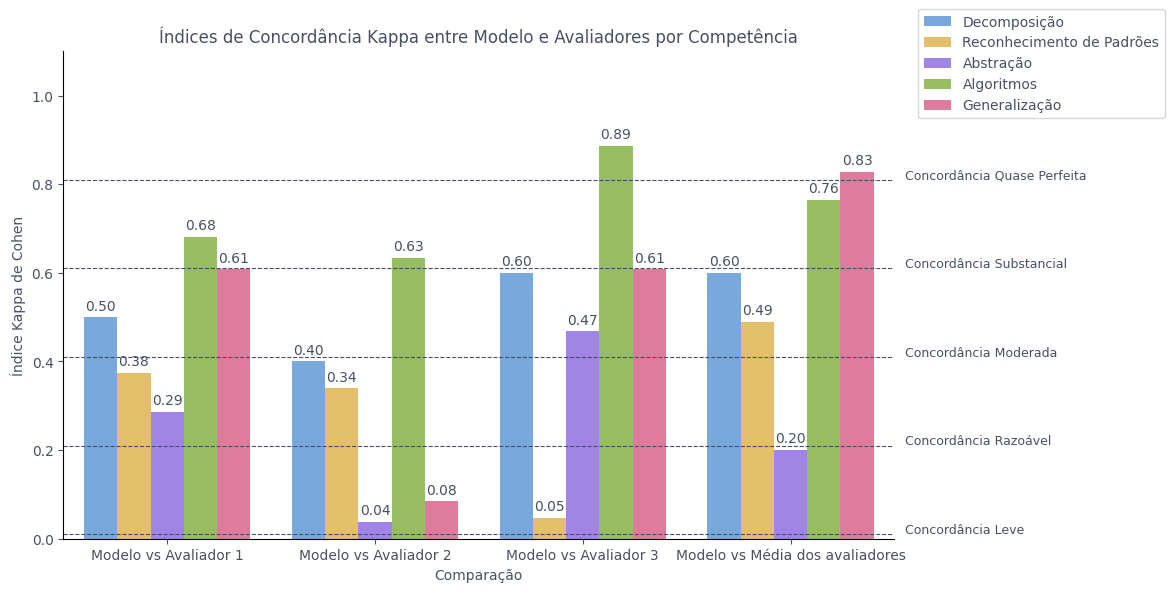

In [ ]:
grafico_concordancia_modelo_avaliadores_piloto()

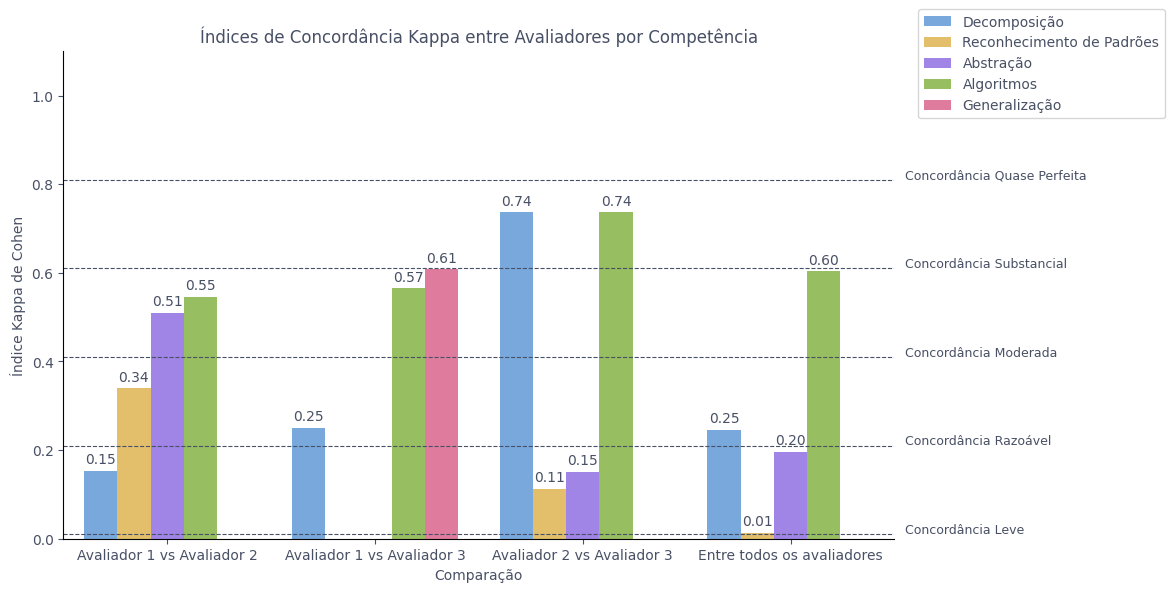

In [ ]:
grafico_concordancia_avaliadores_piloto()

In [ ]:
display(gerar_tabela_porcentagem_concordancia(piloto_df, possible_competencies, DEFINICOES))

,Av1 vs Av2 (%),Av1 vs Av3 (%),Av2 vs Av3 (%),Av1 vs Modelo (%),Av2 vs Modelo (%),Av3 vs Modelo (%),Média Avs vs Modelo (%)
Competência,,,,,,,
Decomposição,45.0,55.0,90.0,75.0,70.0,80.0,80.0
Reconhecimento de Padrões,65.0,50.0,45.0,70.0,65.0,60.0,75.0
Abstração,75.0,50.0,55.0,65.0,50.0,75.0,60.0
Algoritmos,80.0,80.0,90.0,85.0,85.0,95.0,90.0
Generalização,25.0,90.0,25.0,90.0,35.0,90.0,95.0


In [ ]:
display(gerar_tabela_kappa_concordancia(piloto_df, possible_competencies, DEFINICOES))

,Av1 vs Av2 (Kappa),Av1 vs Av3 (Kappa),Av2 vs Av3 (Kappa),Fleiss Kappa (Avs),Av1 vs Modelo (Kappa),Av2 vs Modelo (Kappa),Av3 vs Modelo (Kappa),Média Avs vs Modelo (Kappa)
Competência,,,,,,,,
Decomposição,0.15,0.25,0.74,0.25,0.50,0.40,0.60,0.60
Reconhecimento de Padrões,0.34,-0.19,0.11,0.01,0.38,0.34,0.05,0.49
Abstração,0.51,-0.03,0.15,0.20,0.29,0.04,0.47,0.20
Algoritmos,0.55,0.57,0.74,0.60,0.68,0.63,0.89,0.76
Generalização,-0.06,0.61,-0.06,-0.15,0.61,0.08,0.61,0.83


In [ ]:
display(gerar_porcentagem_existencia_competencia(piloto_df, possible_competencies, DEFINICOES))

,Avaliador 1 (%),Avaliador 2 (%),Avaliador 3 (%),Média Avaliadores (%),Modelo (it1) (%)
Competência,,,,,
Decomposição,25.0,80.0,70.0,70.0,50.0
Reconhecimento de Padrões,40.0,65.0,10.0,45.0,40.0
Abstração,45.0,60.0,35.0,50.0,40.0
Algoritmos,60.0,80.0,70.0,75.0,65.0
Generalização,15.0,80.0,15.0,20.0,15.0


## Experimento de validação

O experimento de validação contou com 30 questões, consideradas suficientes para o tamanho da população (209 questões-problema).

### Organização do dataset

In [ ]:
"""
#Gerando a amostra piloto do dataset

df_amostra = qps_ds.sample(n=20)

output_file_name = 'dataset_piloto.csv'
df_amostra.to_csv(output_file_name, index=False, encoding='utf-8')
"""

"\n#Gerando a amostra piloto do dataset\n\ndf_amostra = qps_ds.sample(n=20)\n\noutput_file_name = 'dataset_piloto.csv'\ndf_amostra.to_csv(output_file_name, index=False, encoding='utf-8')\n"

In [37]:
!wget -q -O dataset_validacao.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_validacao/dados_sem_anotacao/dataset_validacao.csv'

validacao_ds = pd.read_csv('dataset_validacao.csv')

In [38]:
validacao_ds['prompt'] = validacao_ds.apply(gerar_prompt, axis = 1)

In [ ]:
n_questao = 1
questao = validacao_ds.iloc[n_questao]
#print(questao["prompt"])
#print(recupera_resposta(questao))

###Iterações do modelo

In [ ]:
validacao_ds = iteracao_prompt(validacao_ds, 1)

100%|██████████| 30/30 [00:29<00:00,  1.01it/s]


In [ ]:
validacao_ds = iteracao_prompt(validacao_ds, 2)

100%|██████████| 30/30 [00:24<00:00,  1.24it/s]


In [ ]:
validacao_ds = iteracao_prompt(validacao_ds, 3)

100%|██████████| 30/30 [00:26<00:00,  1.13it/s]


In [ ]:
validacao_ds.to_csv(f'dataset_modelo_validacao.csv', index=False)

###Comparando com a avaliação humana

In [39]:
!wget -q -O dataset_avs_validacao.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_validacao/anotacoes_humanas/dataset_avs_validacao.csv'
!wget -q -O dataset_modelo_validacao.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_validacao/anotacoes_automaticas/dataset_modelo_validacao.csv'

avs_ds = pd.read_csv('dataset_avs_validacao.csv')
md_validacao_ds = pd.read_csv('dataset_modelo_validacao.csv')

In [ ]:
n_avs = 3
avs_columns_to_merge = ['id']
for i in range(1, n_avs+1):
    for comp in possible_competencies:
        avs_columns_to_merge.append(f'av{i}_{comp}')

validacao_df = md_validacao_ds.merge(avs_ds[avs_columns_to_merge], on='id', how='left')

In [ ]:
for comp in possible_competencies:
    evaluator_cols = [f'av1_{comp}', f'av2_{comp}', f'av3_{comp}']
    iteration_cols = [f'it1_{comp}', f'it2_{comp}', f'it3_{comp}']
    validacao_df[f'avs_{comp}'] = (validacao_df[evaluator_cols].astype(int).sum(axis=1) >= 2)
    validacao_df[f'its_{comp}'] = (validacao_df[iteration_cols].astype(int).sum(axis=1) >= 2)

In [ ]:
validacao_df.head(1)

,id,enunciado,prompt,it1_comp_decomposicao,it1_comp_reconhecimento_padroes,it1_comp_abstracao,it1_comp_algoritmos,it1_comp_generalizacao,it2_comp_decomposicao,it2_comp_reconhecimento_padroes,...,avs_comp_decomposicao,its_comp_decomposicao,avs_comp_reconhecimento_padroes,its_comp_reconhecimento_padroes,avs_comp_abstracao,its_comp_abstracao,avs_comp_algoritmos,its_comp_algoritmos,avs_comp_generalizacao,its_comp_generalizacao
0,2008-03,"Considere as imagens $I_1$, dada por $I_1(i,j)...","\nQUESTÃO:\nConsidere as imagens $I_1$, dada p...",True,False,False,True,False,False,True,...,True,True,False,False,False,False,True,True,False,False


In [ ]:
validacao_df.to_csv('dataset_comparacao_validacao.csv',index=False)

In [ ]:
def resultados(prefixo1, prefixo2):
  print(f"Resultados do experimento entre {prefixo1} e {prefixo2}\n")

  print("--- Relatórios por Competência ---")
  for comp in possible_competencies:
      competency_name = DEFINICOES[comp]['nome']
      print(f"\nComparando competência: {competency_name}")
      relatorio_comp_validacao(f'{prefixo1}_{comp}', f'{prefixo2}_{comp}')
      print("_____________________________________________________________")

  print("\n--- Relatório por Questão (Match Total de Competências) ---")
  relatorio_questao_validacao(prefixo1, prefixo2)
  print("_____________________________________________________________")

####Resultados entre avaliadores

Nesta etapa, é necessário pontuar que choques contínuos de horários impediram os avaliadores de continuar alinhando suas visões sobre as competências. Assim, nota-se que a concordância nem sempre atinge as faixas desejadas. Além disso, as classificações do avaliador 2 para algumas competências são notoriamente distintas das classificações dos outros avaliadores, o que também foi prejudicado pela falta de encontros posteriores para conversar sobre as questões.

In [ ]:
resultados('av1','av2')

Resultados do experimento entre av1 e av2

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 15 de 30
Porcentagem de correspondências: 50.00%
Índice de concordância Kappa: 0.18
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 10 de 30
Porcentagem de correspondências: 33.33%
Índice de concordância Kappa: 0.03
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 25 de 30
Porcentagem de correspondências: 83.33%
Índice de concordância Kappa: 0.67
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
resultados('av1','av3')

Resultados do experimento entre av1 e av3

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 23 de 30
Porcentagem de correspondências: 76.67%
Índice de concordância Kappa: 0.49
Nível de concordância: Concordância moderada
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 26 de 30
Porcentagem de correspondências: 86.67%
Índice de concordância Kappa: 0.68
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 24 de 30
Porcentagem de correspondências: 80.00%
Índice de concordância Kappa: 0.60
Nível de concordância: Concordância moderada
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordânci

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
resultados('av2','av3')

Resultados do experimento entre av2 e av3

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 16 de 30
Porcentagem de correspondências: 53.33%
Índice de concordância Kappa: 0.21
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 10 de 30
Porcentagem de correspondências: 33.33%
Índice de concordância Kappa: 0.03
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 25 de 30
Porcentagem de correspondências: 83.33%
Índice de concordância Kappa: 0.66
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 30 de 30
Porcentagem de correspondências: 100.00%
Índice de concordância K

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


####Resultados entre iterações

In [ ]:
resultados('it1','it2')

Resultados do experimento entre it1 e it2

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.87
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.93
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.87
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
resultados('it1','it3')

Resultados do experimento entre it1 e it3

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.93
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.86
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 27 de 30
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.80
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
resultados('it2','it3')

Resultados do experimento entre it2 e it3

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 27 de 30
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.80
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 27 de 30
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.79
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 27 de 30
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.80
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de co

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


####Resultados entre avaliadores e média dos avaliadores

In [ ]:
resultados('av1','avs')

Resultados do experimento entre av1 e avs

--- Relatórios por Competência ---

Comparando competência: Decomposição


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Número de correspondências: 26 de 30
Porcentagem de correspondências: 86.67%
Índice de concordância Kappa: 0.73
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.85
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 27 de 30
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.80
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.86
Nível de concordância: Concordância quase perfeita
__________________________________________

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
resultados('av2','avs')

Resultados do experimento entre av2 e avs

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 19 de 30
Porcentagem de correspondências: 63.33%
Índice de concordância Kappa: 0.30
Nível de concordância: Concordância razoável
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 12 de 30
Porcentagem de correspondências: 40.00%
Índice de concordância Kappa: 0.04
Nível de concordância: Concordância leve
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.86
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 30 de 30
Porcentagem de correspondências: 100.00%
Índice de concordânci

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [ ]:
resultados('av3','avs')

Resultados do experimento entre av3 e avs

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 27 de 30
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.80
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 28 de 30
Porcentagem de correspondências: 93.33%
Índice de concordância Kappa: 0.85
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 27 de 30
Porcentagem de correspondências: 90.00%
Índice de concordância Kappa: 0.78
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 30 de 30
Porcentagem de correspondências: 100.00%
Índice de c

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


####Resultados entre média das iterações e média dos avaliadores

In [ ]:
resultados('its','avs')

Resultados do experimento entre its e avs

--- Relatórios por Competência ---

Comparando competência: Decomposição

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice de concordância Kappa: 0.93
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Reconhecimento de Padrões

Número de correspondências: 30 de 30
Porcentagem de correspondências: 100.00%
Índice de concordância Kappa: 1.00
Nível de concordância: Concordância quase perfeita
_____________________________________________________________

Comparando competência: Abstração

Número de correspondências: 26 de 30
Porcentagem de correspondências: 86.67%
Índice de concordância Kappa: 0.74
Nível de concordância: Concordância substancial
_____________________________________________________________

Comparando competência: Algoritmos

Número de correspondências: 29 de 30
Porcentagem de correspondências: 96.67%
Índice d

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


####Divergências entre média dos avaliadores e média das iterações

In [ ]:
def divergencias_media(comp_numeric_id):
  comp = possible_competencies[comp_numeric_id]
  competency_name = DEFINICOES[comp]['nome']

  comparison_cols = [
      f'its_{comp}', f'avs_{comp}'
  ]

  divergent_questions = validacao_df[
      validacao_df[comparison_cols].nunique(axis=1) > 1
  ]

  if not divergent_questions.empty:
      print(f"Questões com divergência na classificação da competência {competency_name}")
      display_cols = ['id', 'enunciado'] + comparison_cols
      display(divergent_questions[display_cols])
  else:
      print(f"Não houve divergências na classificação da competência {competency_name}.")

In [ ]:
divergencias_media(0)

Questões com divergência na classificação da competência Decomposição


,id,enunciado,its_comp_decomposicao,avs_comp_decomposicao
20,2008-13,Observe a seguinte gramática:\n```\n DECL → I...,True,False


In [ ]:
divergencias_media(1)

Não houve divergências na classificação da competência Reconhecimento de Padrões.


In [ ]:
divergencias_media(2)

Questões com divergência na classificação da competência Abstração


,id,enunciado,its_comp_abstracao,avs_comp_abstracao
8,2010-34,Considere o conjunto de operações descritas a ...,True,False
16,2012-28,"Nas linguagens de programação, uma questão imp...",True,False
20,2008-13,Observe a seguinte gramática:\n```\n DECL → I...,True,False
28,2014-03,Acerca da posição relativa das retas $r$ e $s$...,True,False


In [ ]:
divergencias_media(3)

Questões com divergência na classificação da competência Algoritmos


,id,enunciado,its_comp_algoritmos,avs_comp_algoritmos
12,2013-51,Uma empresa de auditoria foi contratada para a...,True,False


In [ ]:
divergencias_media(4)

Questões com divergência na classificação da competência Generalização


,id,enunciado,its_comp_generalizacao,avs_comp_generalizacao
15,2007-24,Considere um arquivo texto que contenha uma me...,False,True


###Funções para visualização de dados

In [ ]:
competency_palette = {
      DEFINICOES["comp_decomposicao"]["nome"]: '#67A8ED',  #azul
      DEFINICOES["comp_reconhecimento_padroes"]["nome"]: '#F7C758', #amarelo
      DEFINICOES["comp_abstracao"]["nome"]: '#9974F6',  #lilás
      DEFINICOES["comp_algoritmos"]["nome"]: '#9ACE51', #verde
      DEFINICOES["comp_generalizacao"]["nome"]: '#EF6C98' #rosa
  }

In [ ]:
def grafico_concordancia_modelo_avaliadores():
  all_kappas_data = []

  hex_codes = {
      "green": "#C7D9B7",
      "green_2": "#6B8851",
      "green_3": "#A4DB77",
      "red": "#CF8E93",
      "red_2": "#8C5257",
      "red_3": "#BB4C55",
      "gray": "#485065"
  }

  for comp_id, comp in enumerate(possible_competencies):
    comp_name = DEFINICOES[comp]['nome']

    kappa_val = c_kappa(validacao_df, f'its_{comp}', f'avs_{comp}')
    kappa_val = 1.0 if np.isnan(kappa_val) else kappa_val

    bar_color = hex_codes["green_3"] if kappa_val > 0.6 else hex_codes["red_3"]

    all_kappas_data.append({
        'Competência': comp_name,
        'Kappa': kappa_val,
        'BarColor': bar_color
    })

  plot_df = pd.DataFrame(all_kappas_data)

  plt.rcParams['text.color'] = hex_codes["gray"]
  plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
  plt.rcParams['xtick.color'] = hex_codes["gray"]
  plt.rcParams['ytick.color'] = hex_codes["gray"]

  plt.figure(figsize=(14, 6))
  ax = plt.gca()

  colors_for_bars = plot_df['BarColor'].tolist()

  sns.barplot(x='Competência', y='Kappa', data=plot_df, palette=colors_for_bars, ax=ax)

  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)

  plt.xlabel(' ', color=hex_codes["gray"])
  plt.ylabel('Índice Kappa de Cohen', color=hex_codes["gray"])
  plt.title('Índices de Concordância Kappa entre Média do Modelo e Média dos Avaliadores por Competência', color=hex_codes["gray"])
  plt.ylim(0, 1.1)

  kappa_level_definitions = [
      (0.01, "Concordância Leve"),
      (0.21, "Concordância Razoável"),
      (0.41, "Concordância Moderada"),
      (0.61, "Concordância Substancial"),
      (0.81, "Concordância Quase Perfeita")
  ]

  for threshold, level_text in kappa_level_definitions:
      line_and_text_color = hex_codes["gray"]
      plt.axhline(y=threshold, color=line_and_text_color, linestyle='--', linewidth=0.8)
      plt.text(ax.get_xlim()[1] + 0.05, threshold + 0.01, level_text,
              va='center', ha='left', color=line_and_text_color, fontsize=9)

  for container in ax.containers:
      for patch in container.patches:
          height = patch.get_height()
          ax.annotate(f'{height:.2f}',
                      xy=(patch.get_x() + patch.get_width() / 2, height),
                      xytext=(0, 3),
                      textcoords="offset points",
                      ha='center', va='bottom', color=hex_codes["gray"])

  plt.xticks(color=hex_codes["gray"])
  plt.yticks(color=hex_codes["gray"])

  plt.tight_layout(rect=[0, 0, 0.85, 1])
  plt.show()

In [ ]:
def grafico_concordancia_interna(prefix):
  all_kappas_data = []

  if prefix == 'av':
    col_base = 'av'
    title_text = 'Índices de Concordância Kappa entre Avaliadores por Competência'
    labels_template = ['Avaliador 1 vs Avaliador 2', 'Avaliador 1 vs Avaliador 3','Avaliador 2 vs Avaliador 3','Entre todos os avaliadores',]
  elif prefix == 'it':
    col_base = 'it'
    title_text = 'Índices de Concordância Kappa entre Iterações por Competência'
    labels_template = ['Iteração 1 vs Iteração 2', 'Iteração 1 vs Iteração 3','Iteração 2 vs Iteração 3','Entre todas as iterações',]
  else:
    raise ValueError("Prefix must be 'av' or 'it'")

  for comp_id, comp in enumerate(possible_competencies):
    comp_name = DEFINICOES[comp]['nome']

    col1 = f'{col_base}1_{comp}'
    col2 = f'{col_base}2_{comp}'
    col3 = f'{col_base}3_{comp}'

    k_1_2 = c_kappa(validacao_df, col1, col2)
    k_1_3 = c_kappa(validacao_df, col1, col3)
    k_2_3 = c_kappa(validacao_df, col2, col3)
    k_all = f_kappa(validacao_df, [col1, col2, col3])

    labels = labels_template
    kappas = [k_1_2, k_1_3, k_2_3, k_all]

    for label, kappa_val in zip(labels, kappas):
      kappa_val = 1.0 if np.isnan(kappa_val) else kappa_val
      all_kappas_data.append({
          'Competência': comp_name,
          'Comparação': label,
          'Kappa': kappa_val
      })

  plot_df = pd.DataFrame(all_kappas_data)

  hex_codes = {
      "green": "#C7D9B7",
      "green_2": "#6B8851",
      "green_3": "#A4DB77",
      "red": "#CF8E93",
      "red_2": "#8C5257",
      "red_3": "#BB4C55",
      "gray": "#485065"
  }

  plt.rcParams['text.color'] = hex_codes["gray"]
  plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
  plt.rcParams['xtick.color'] = hex_codes["gray"]
  plt.rcParams['ytick.color'] = hex_codes["gray"]

  plt.figure(figsize=(14, 6))
  ax = plt.gca()

  sns.barplot(x='Comparação', y='Kappa', hue='Competência', data=plot_df, palette=competency_palette, ax=ax)

  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)

  plt.xlabel('Comparação', color=hex_codes["gray"])
  plt.ylabel('Índice Kappa de Cohen', color=hex_codes["gray"])
  plt.title(title_text, color=hex_codes["gray"])
  plt.ylim(0, 1.1)

  kappa_level_definitions = [
      (0.01, "Concordância Leve"),
      (0.21, "Concordância Razoável"),
      (0.41, "Concordância Moderada"),
      (0.61, "Concordância Substancial"),
      (0.81, "Concordância Quase Perfeita")
  ]

  for threshold, level_text in kappa_level_definitions:
      line_and_text_color = hex_codes["gray"]
      plt.axhline(y=threshold, color=line_and_text_color, linestyle='--', linewidth=0.8)
      plt.text(ax.get_xlim()[1] + 0.05, threshold + 0.01, level_text,
              va='center', ha='left', color=line_and_text_color, fontsize=9)

  for container in ax.containers:
      for patch in container.patches:
          height = patch.get_height()
          ax.annotate(f'{height:.2f}',
                      xy=(patch.get_x() + patch.get_width() / 2, height),
                      xytext=(0, 3),
                      textcoords="offset points",
                      ha='center', va='bottom', color=hex_codes["gray"])

  ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.1))
  plt.xticks(color=hex_codes["gray"])
  plt.yticks(color=hex_codes["gray"])

  plt.tight_layout(rect=[0, 0, 0.85, 1])
  plt.show()

In [ ]:
def grafico_porcentagem_competencias(df, competencies, definitions):
    plot_data = []

    for comp in competencies:
        iteration_cols = [f'it{i}_{comp}' for i in range(1, 4)]
        existing_iteration_cols = [col for col in iteration_cols if col in df.columns]

        if not existing_iteration_cols:
            df[f'its_{comp}'] = False
        else:
            df[f'its_{comp}'] = (df[existing_iteration_cols].astype(int).mean(axis=1) >= 0.5)

    categories_to_check = {
        'Avaliador 1': 'av1',
        'Avaliador 2': 'av2',
        'Avaliador 3': 'av3',
        'Média Avaliadores': 'avs',
        'Iteração 1': 'it1',
        'Iteração 2': 'it2',
        'Iteração 3': 'it3',
        'Média Iterações': 'its'
    }

    for comp in competencies:
        comp_name = definitions[comp]['nome']
        for category_label, prefix in categories_to_check.items():
            col_name = f'{prefix}_{comp}'
            if col_name in df.columns:
                percentage = df[col_name].mean() * 100
                plot_data.append({
                    'Competência': comp_name,
                    'Categoria de Classificação': category_label,
                    'Porcentagem': percentage
                })

    plot_df = pd.DataFrame(plot_data)

    if plot_df.empty:
        print("Nenhum dado disponível para plotar. Verifique o dataframe e os nomes das colunas.")
        return

    hex_codes = {
        "green": "#C7D9B7",
        "green_2": "#6B8851",
        "green_3": "#A4DB77",
        "red": "#CF8E93",
        "red_2": "#8C5257",
        "red_3": "#BB4C55",
        "gray": "#485065"
    }

    plt.rcParams['text.color'] = hex_codes["gray"]
    plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
    plt.rcParams['xtick.color'] = hex_codes["gray"]
    plt.rcParams['ytick.color'] = hex_codes["gray"]

    plt.figure(figsize=(16, 8))
    ax = plt.gca()

    sns.barplot(x='Categoria de Classificação', y='Porcentagem', hue='Competência', data=plot_df, palette=competency_palette, ax=ax)

    ax.spines['top'].set_visible(False);
    ax.spines['right'].set_visible(False);
    ax.spines['left'].set_color(hex_codes["gray"]);
    ax.spines['bottom'].set_color(hex_codes["gray"]);

    plt.xlabel('Categoria de Classificação', color=hex_codes["gray"])
    plt.ylabel('Porcentagem de Ocorrência (%)', color=hex_codes["gray"])
    plt.title('Porcentagem de Ocorrência de Competências no Dataset Piloto', color=hex_codes["gray"])
    plt.ylim(0, 100)

    plt.xticks(color=hex_codes["gray"])
    plt.yticks(color=hex_codes["gray"])

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=8, color=hex_codes["gray"])

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()

###Funções para geração de tabelas

In [ ]:
def gerar_tabela_porcentagem_concordancia_detalhada_vs_media(df, possible_competencies, definitions):
    data = []

    for comp in possible_competencies:
        comp_name = definitions[comp]['nome']

        _, p_av1_avs = concordancia_simples_2_colunas(df, f'av1_{comp}', f'avs_{comp}')
        _, p_av2_avs = concordancia_simples_2_colunas(df, f'av2_{comp}', f'avs_{comp}')
        _, p_av3_avs = concordancia_simples_2_colunas(df, f'av3_{comp}', f'avs_{comp}')

        _, p_it1_avs = concordancia_simples_2_colunas(df, f'it1_{comp}', f'avs_{comp}')
        _, p_it2_avs = concordancia_simples_2_colunas(df, f'it2_{comp}', f'avs_{comp}')
        _, p_it3_avs = concordancia_simples_2_colunas(df, f'it3_{comp}', f'avs_{comp}')

        _, p_its_avs = concordancia_simples_2_colunas(df, f'its_{comp}', f'avs_{comp}')

        data.append({
            'Competência': comp_name,
            'Av1 vs Média Avs (%)': round(p_av1_avs, 2),
            'Av2 vs Média Avs (%)': round(p_av2_avs, 2),
            'Av3 vs Média Avs (%)': round(p_av3_avs, 2),
            'It1 vs Média Avs (%)': round(p_it1_avs, 2),
            'It2 vs Média Avs (%)': round(p_it2_avs, 2),
            'It3 vs Média Avs (%)': round(p_it3_avs, 2),
            'Média Its vs Média Avs (%)': round(p_its_avs, 2)
        })

    df_results = pd.DataFrame(data)
    df_results = df_results.set_index('Competência')
    return df_results

In [ ]:
def gerar_tabela_kappa_concordancia_detalhada_vs_media(df, possible_competencies, definitions):
    data = []

    for comp in possible_competencies:
        comp_name = definitions[comp]['nome']

        k_av1_avs = c_kappa(df, f'av1_{comp}', f'avs_{comp}')
        k_av2_avs = c_kappa(df, f'av2_{comp}', f'avs_{comp}')
        k_av3_avs = c_kappa(df, f'av3_{comp}', f'avs_{comp}')

        k_it1_avs = c_kappa(df, f'it1_{comp}', f'avs_{comp}')
        k_it2_avs = c_kappa(df, f'it2_{comp}', f'avs_{comp}')
        k_it3_avs = c_kappa(df, f'it3_{comp}', f'avs_{comp}')

        k_its_avs = c_kappa(df, f'its_{comp}', f'avs_{comp}')

        data.append({
            'Competência': comp_name,
            'Av1 vs Média Avs (Kappa)': round(k_av1_avs, 2) if not np.isnan(k_av1_avs) else np.nan,
            'Av2 vs Média Avs (Kappa)': round(k_av2_avs, 2) if not np.isnan(k_av2_avs) else np.nan,
            'Av3 vs Média Avs (Kappa)': round(k_av3_avs, 2) if not np.isnan(k_av3_avs) else np.nan,
            'It1 vs Média Avs (Kappa)': round(k_it1_avs, 2) if not np.isnan(k_it1_avs) else np.nan,
            'It2 vs Média Avs (Kappa)': round(k_it2_avs, 2) if not np.isnan(k_it2_avs) else np.nan,
            'It3 vs Média Avs (Kappa)': round(k_it3_avs, 2) if not np.isnan(k_it3_avs) else np.nan,
            'Média Its vs Média Avs (Kappa)': round(k_its_avs, 2) if not np.isnan(k_its_avs) else np.nan
        })

    df_results = pd.DataFrame(data)
    df_results = df_results.set_index('Competência')
    return df_results

###Visualizações de dados

/tmp/ipykernel_1280/2276005111.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Competência', y='Kappa', data=plot_df, palette=colors_for_bars, ax=ax)


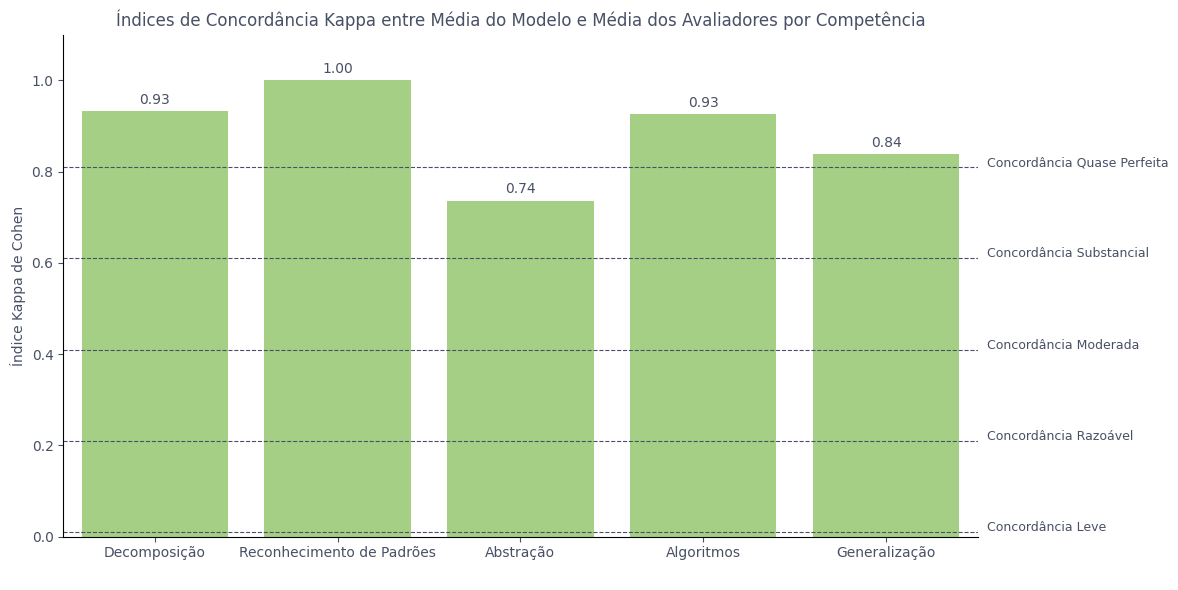

In [ ]:
grafico_concordancia_modelo_avaliadores()

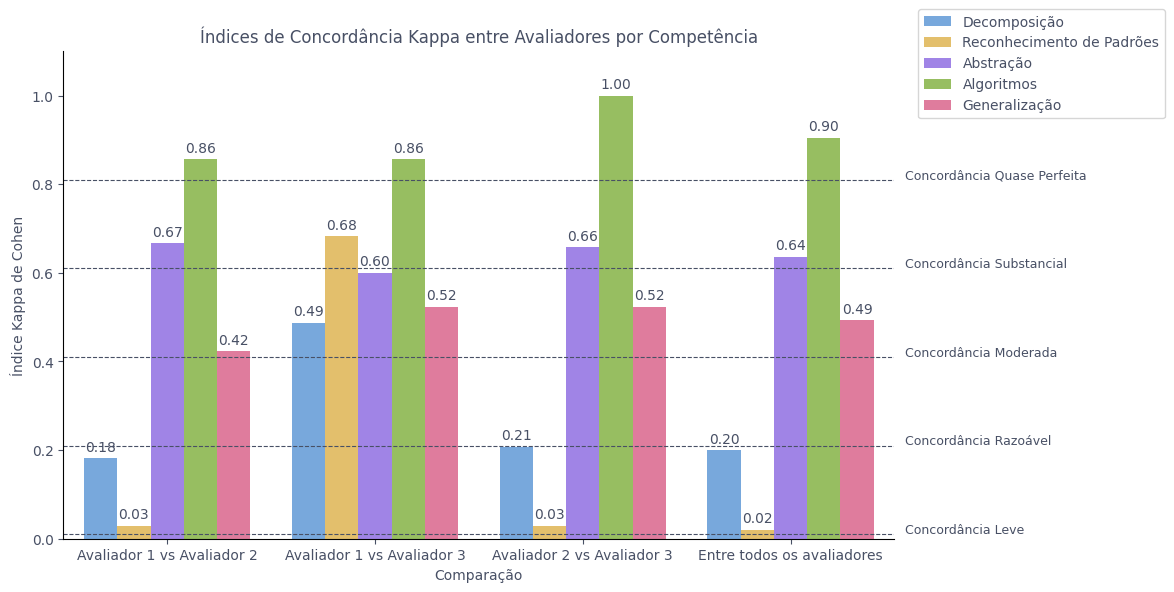

In [ ]:
grafico_concordancia_interna("av")

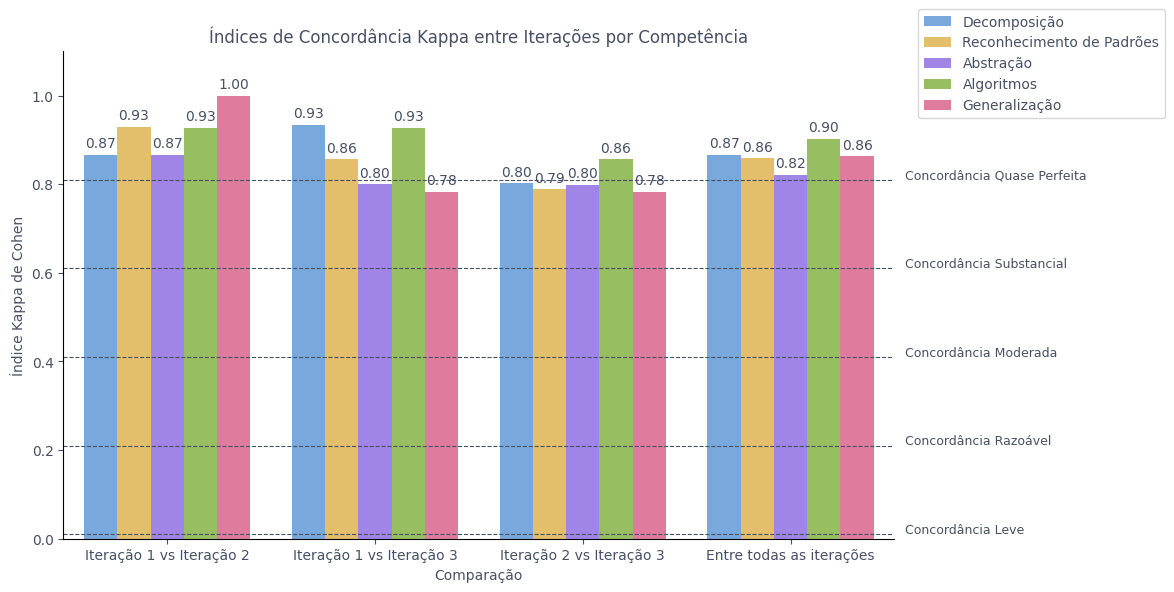

In [ ]:
grafico_concordancia_interna("it")

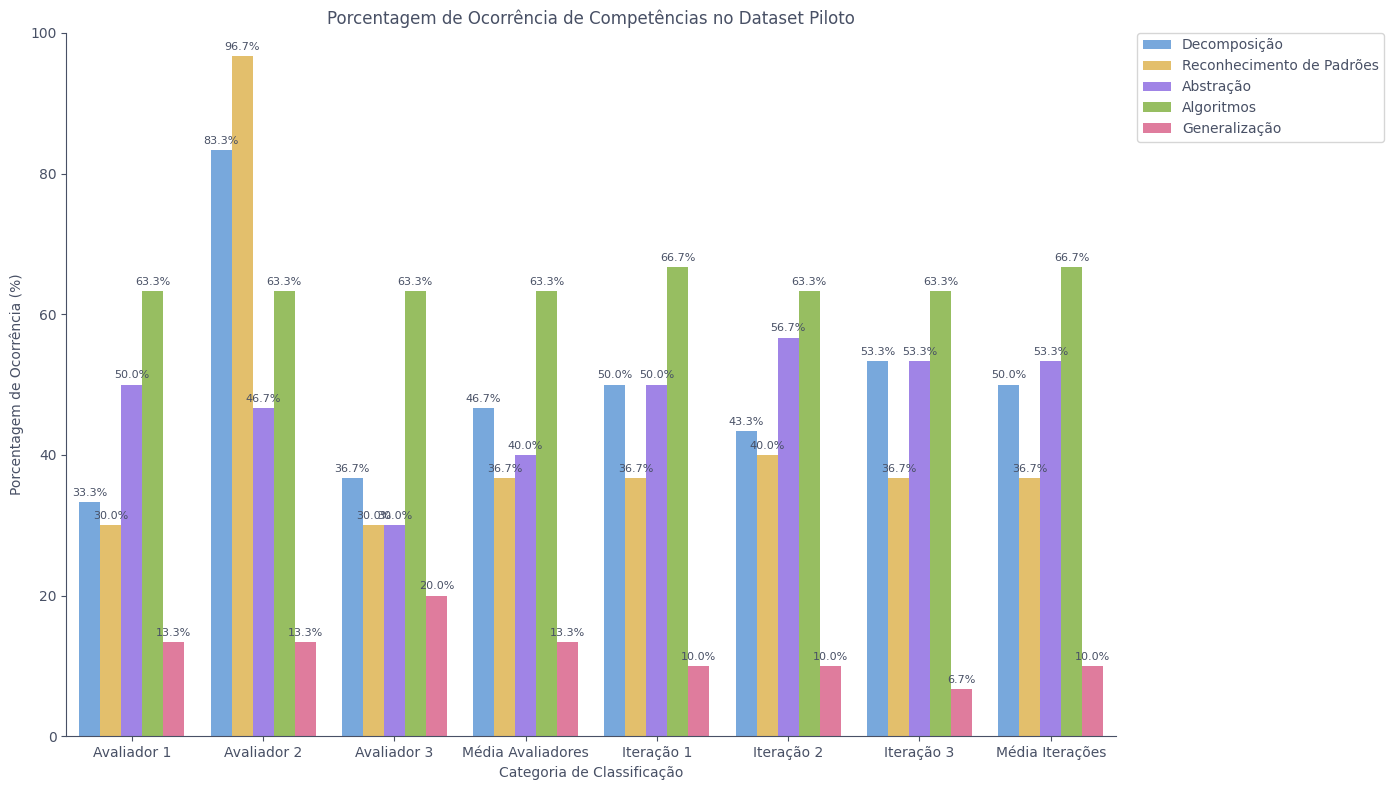

In [ ]:
grafico_porcentagem_competencias(validacao_df, possible_competencies, DEFINICOES)

In [ ]:
display(gerar_tabela_porcentagem_concordancia_detalhada_vs_media(validacao_df, possible_competencies, DEFINICOES))

,Av1 vs Média Avs (%),Av2 vs Média Avs (%),Av3 vs Média Avs (%),It1 vs Média Avs (%),It2 vs Média Avs (%),It3 vs Média Avs (%),Média Its vs Média Avs (%)
Competência,,,,,,,
Decomposição,86.67,63.33,90.00,96.67,90.00,93.33,96.67
Reconhecimento de Padrões,93.33,40.00,93.33,100.00,96.67,93.33,100.00
Abstração,90.00,93.33,90.00,83.33,83.33,86.67,86.67
Algoritmos,93.33,100.00,100.00,96.67,93.33,100.00,96.67
Generalização,93.33,93.33,93.33,96.67,96.67,93.33,96.67


In [ ]:
display(gerar_tabela_kappa_concordancia_detalhada_vs_media(validacao_df, possible_competencies, DEFINICOES))

,Av1 vs Média Avs (Kappa),Av2 vs Média Avs (Kappa),Av3 vs Média Avs (Kappa),It1 vs Média Avs (Kappa),It2 vs Média Avs (Kappa),It3 vs Média Avs (Kappa),Média Its vs Média Avs (Kappa)
Competência,,,,,,,
Decomposição,0.73,0.30,0.80,0.93,0.80,0.87,0.93
Reconhecimento de Padrões,0.85,0.04,0.85,1.00,0.93,0.86,1.00
Abstração,0.80,0.86,0.78,0.67,0.68,0.74,0.74
Algoritmos,0.86,1.00,1.00,0.93,0.86,1.00,0.93
Generalização,0.71,0.71,0.76,0.84,0.84,0.63,0.84


##Análise de divergências

###Organizando o dataset

In [40]:
!wget -q -O dataset_comparacao_validacao.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_validacao/dataset_comparacao_validacao.csv'

comparacao_df = pd.read_csv('dataset_comparacao_validacao.csv')

In [ ]:
all_divergent_dfs = []

for comp_numeric_id in range(0,5):
  comp = possible_competencies[comp_numeric_id]
  competency_name = DEFINICOES[comp]['nome']

  comparison_cols = [
      f'its_{comp}', f'avs_{comp}'
  ]

  current_divergent_df = comparacao_df[
      comparacao_df[comparison_cols].nunique(axis=1) > 1
  ]
  all_divergent_dfs.append(current_divergent_df)

divergencias_df = pd.concat(all_divergent_dfs, ignore_index=True)
divergencias_df = divergencias_df.drop_duplicates(subset=['id'])

In [ ]:
columns_to_keep = ['id', 'enunciado']
for col in divergencias_df.columns:
    if col.startswith('avs_') or col.startswith('its_'):
        columns_to_keep.append(col)
divergencias_df = divergencias_df[columns_to_keep]

In [ ]:
divergencias_df.head(1)

,id,enunciado,avs_comp_decomposicao,its_comp_decomposicao,avs_comp_reconhecimento_padroes,its_comp_reconhecimento_padroes,avs_comp_abstracao,its_comp_abstracao,avs_comp_algoritmos,its_comp_algoritmos,avs_comp_generalizacao,its_comp_generalizacao
0,2008-13,Observe a seguinte gramática:\n```\n DECL → I...,False,True,True,True,False,True,False,False,False,False


###Divergências

In [ ]:
def divergencias_media(comp_numeric_id):
  comp = possible_competencies[comp_numeric_id]
  competency_name = DEFINICOES[comp]['nome']

  comparison_cols = [
      f'its_{comp}', f'avs_{comp}'
  ]

  divergent_questions = comparacao_df[
      comparacao_df[comparison_cols].nunique(axis=1) > 1
  ]

  if not divergent_questions.empty:
      print(f"Questões com divergência na classificação da competência {competency_name}")
      display_cols = ['id', 'enunciado'] + comparison_cols
      display(divergent_questions[display_cols])
  else:
      print(f"Não houve divergências na classificação da competência {competency_name}.")

In [ ]:
divergencias_media(0)

Questões com divergência na classificação da competência Decomposição


,id,enunciado,its_comp_decomposicao,avs_comp_decomposicao
20,2008-13,Observe a seguinte gramática:\n```\n DECL → I...,True,False


In [ ]:
divergencias_media(1)

Não houve divergências na classificação da competência Reconhecimento de Padrões.


In [ ]:
divergencias_media(2)

Questões com divergência na classificação da competência Abstração


,id,enunciado,its_comp_abstracao,avs_comp_abstracao
8,2010-34,Considere o conjunto de operações descritas a ...,True,False
16,2012-28,"Nas linguagens de programação, uma questão imp...",True,False
20,2008-13,Observe a seguinte gramática:\n```\n DECL → I...,True,False
28,2014-03,Acerca da posição relativa das retas $r$ e $s$...,True,False


In [ ]:
divergencias_media(3)

Questões com divergência na classificação da competência Algoritmos


,id,enunciado,its_comp_algoritmos,avs_comp_algoritmos
12,2013-51,Uma empresa de auditoria foi contratada para a...,True,False


In [ ]:
divergencias_media(4)

Questões com divergência na classificação da competência Generalização


,id,enunciado,its_comp_generalizacao,avs_comp_generalizacao
15,2007-24,Considere um arquivo texto que contenha uma me...,False,True


In [ ]:
total_classifications = 0
total_matches = 0
total_divergences = 0

for comp in possible_competencies:
    its_col = f'its_{comp}'
    avs_col = f'avs_{comp}'

    if its_col in validacao_df.columns and avs_col in validacao_df.columns:
        matches_per_comp = (validacao_df[its_col] == validacao_df[avs_col]).sum()
        total_matches += matches_per_comp

        divergences_per_comp = (validacao_df[its_col] != validacao_df[avs_col]).sum()
        total_divergences += divergences_per_comp

        total_classifications += len(validacao_df)


if total_classifications > 0:
    percentage_matches = (total_matches / total_classifications) * 100
    percentage_divergences = (total_divergences / total_classifications) * 100
else:
    percentage_matches = 0
    percentage_divergences = 0

print(f"Total de classificações comparadas: {total_classifications}")
print(f"Número de correspondências: {total_matches} ({percentage_matches:.2f}%)")
print(f"Número de divergências: {total_divergences} ({percentage_divergences:.2f}%)")

Total de classificações comparadas: 150
Número de correspondências: 143 (95.33%)
Número de divergências: 7 (4.67%)


###Criação de prompts para a análise

In [ ]:
DIVERGING_PROMPT = """
O foco agora é entender as questões onde sua resposta, dentro do protocolo anterior, divergiu da classificação humana.
Você receberá a questão, o seu veredito anterior e o veredito dos humanos para uma das competências.
Responda com no máximo duas sentenças, justificando sua resposta e porque o seu veredito é válido.
Se for um caso limítrofe, onde você acredita que é possível enxergar ou não enxergar a competência, deixe isso explícito.
Se você está certo de que o seu veredito foi o correto, justifique também.
"""

In [ ]:
REASONING_PROMPT = f"""
O prompt a seguir é o protocolo de anotação que você recebeu para classificar questões:

PROTOCOLO DE CLASSIFICAÇÃO:
'{SYSTEM_PROMPT}'

NOVO COMANDO:
{DIVERGING_PROMPT}
"""

In [ ]:
def gerar_prompt_justificativa(questao, comp):
  PROMPT = f"""
QUESTÃO:
{questao['enunciado']}

COMPETÊNCIA:
{DEFINICOES[comp]['nome']}

SEU VEREDITO:
{questao['its_'+comp]}

VEREDITO HUMANO:
{questao['avs_'+comp]}
"""

  return PROMPT

In [ ]:
def recupera_justificativa(prompt):
  obj = get_completion(prompt, "gpt-5.4", REASONING_PROMPT)
  return (obj.choices[0].message.content)

###Solicitando justificativas do modelo

In [ ]:
justification_prompts_df_data = []

for comp in possible_competencies:
    competency_name = DEFINICOES[comp]['nome']

    divergent_questions = divergencias_df[
        divergencias_df[f'its_{comp}'] != divergencias_df[f'avs_{comp}']
    ]

    if not divergent_questions.empty:
        for index, row in divergent_questions.iterrows():
            justification_prompts_df_data.append({
                'id': row['id'],
                'enunciado': row['enunciado'],
                'competencia': competency_name,
                'classificacao_modelo': row[f'its_{comp}'],
                'classificacao_avaliadores': row[f'avs_{comp}'],
                'prompt': gerar_prompt_justificativa(row, comp)
            })

justification_prompts_df = pd.DataFrame(justification_prompts_df_data)

In [ ]:
justification_prompts_df['justificativa_modelo'] = justification_prompts_df['prompt'].progress_apply(recupera_justificativa)

100%|██████████| 7/7 [00:15<00:00,  2.23s/it]


In [ ]:
justification_prompts_df.head(1)

,id,enunciado,competencia,classificacao_modelo,classificacao_avaliadores,prompt,justificativa_modelo
0,2008-13,Observe a seguinte gramática:\n```\n DECL → I...,Decomposição,True,False,\nQUESTÃO:\nObserve a seguinte gramática:\n```...,Considerei Decomposição porque resolver a ques...


In [ ]:
justification_prompts_df.to_csv('justificativas_divergencias_validacao.csv',index=False)

###Análise das justificativas

A análise contou com a criação de novas colunas booleanas: "caso_limitrofe", "houve_discordancia_humana" e "modelo_errou".

Nesta etapa, o pesquisador manualmente analisa as divergências e procura entender se o raciocínio do modelo poderia ser considerado como um acerto, mesmo que diferente da média dos humanos. Casos limítrofes frequentemente confundem o julgamento, fazendo com que a identificação ou não da competência seja uma tarefa ambígua e subjetiva. Assim, a depender da justificativa, o julgamento pode ou não ser considerado um "erro", especialmente se também houve discordância entre avaliadores humanos.

Os casos limítrofes foram considerados aqueles que o modelo explicitamente aponta como limítrofes. A coluna "houve_discordancia_humana" também extrai a possibilidade de haver dúvidas na classificação. Assim, podemos analisar se o modelo costuma discordar em casos onde realmente houve discordância por parte dos humanos.

Abaixo, exibimos os resultados desta análise manual.



In [41]:
!wget -q -O justificativas_divergencias_validacao_analisado.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_validacao/analise_de_divergencias/justificativas_divergencias_validacao_analisado.csv'

justificativas_df = pd.read_csv('justificativas_divergencias_validacao_analisado.csv')

In [42]:
justificativas_df.head(1)

,id,enunciado,competencia,classificacao_modelo,classificacao_avaliadores,justificativa_modelo,caso_limitrofe,houve_discordancia_humana,modelo_errou,justificativa_modelo_errou
0,2008-13,Observe a seguinte gramática:\n```\n DECL → I...,Decomposição,True,False,Considerei Decomposição porque resolver a ques...,True,True,False,A justificativa do modelo espelha o possível e...


In [ ]:
len(justificativas_df)

7

In [ ]:
print("\nDivergências por Competência (Média do Modelo vs Média Avaliadores)")

total_divergences_overall = len(justificativas_df)

for comp in possible_competencies:
    competency_name = DEFINICOES[comp]['nome']
    its_col = f'its_{comp}'
    avs_col = f'avs_{comp}'

    if its_col in validacao_df.columns and avs_col in validacao_df.columns:
        divergences_per_comp = (validacao_df[its_col] != validacao_df[avs_col]).sum()

        percentage_of_total_divergences = (divergences_per_comp / total_divergences_overall) * 100 if total_divergences_overall > 0 else 0

        print(f"\n{competency_name}")
        print(f"  Número de divergências: {divergences_per_comp} ({percentage_of_total_divergences:.2f}% do total de divergências)")
    else:
        print(f"\n{competency_name}")
        print(f"  Colunas '{its_col}' ou '{avs_col}' não encontradas no DataFrame.")


Divergências por Competência (Média do Modelo vs Média Avaliadores)

Decomposição
  Número de divergências: 1 (14.29% do total de divergências)

Reconhecimento de Padrões
  Número de divergências: 0 (0.00% do total de divergências)

Abstração
  Número de divergências: 4 (57.14% do total de divergências)

Algoritmos
  Número de divergências: 1 (14.29% do total de divergências)

Generalização
  Número de divergências: 1 (14.29% do total de divergências)


In [ ]:
borderline_divergences_df = justificativas_df[justificativas_df['caso_limitrofe'] == True]
count_borderline_divergences = len(borderline_divergences_df)
total_divergences = len(justificativas_df)

percentage_borderline_divergences = (count_borderline_divergences / total_divergences) * 100 if total_divergences > 0 else 0

print(f"Número de divergências que são casos limítrofes: {count_borderline_divergences}")
print(f"Porcentagem de divergências limítrofes (do total de divergências): {percentage_borderline_divergences:.2f}%")

Número de divergências que são casos limítrofes: 7
Porcentagem de divergências limítrofes (do total de divergências): 100.00%


In [ ]:
human_disagreement_divergences_df = justificativas_df[justificativas_df['houve_discordancia_humana'] == True]
count_human_disagreement_divergences = len(human_disagreement_divergences_df)
total_divergences = len(justificativas_df)

percentage_human_disagreement_divergences = (count_human_disagreement_divergences / total_divergences) * 100 if total_divergences > 0 else 0

print(f"Número de divergências onde houve discordância humana: {count_human_disagreement_divergences}")
print(f"Porcentagem de divergências com discordância humana (do total de divergências): {percentage_human_disagreement_divergences:.2f}%")

Número de divergências onde houve discordância humana: 5
Porcentagem de divergências com discordância humana (do total de divergências): 71.43%


In [ ]:
data = []
total_divergences = len(justificativas_df)

count_bl_hd = len(justificativas_df[(justificativas_df['caso_limitrofe'] == True) & (justificativas_df['houve_discordancia_humana'] == True)])
percentage_bl_hd = (count_bl_hd / total_divergences) * 100 if total_divergences > 0 else 0
data.append({
    'Categoria': 'Limítrofes e com Discordância Humana',
    'Contagem': count_bl_hd,
    'Porcentagem': f'{percentage_bl_hd:.2f}%'
})

count_bl_no_hd = len(justificativas_df[(justificativas_df['caso_limitrofe'] == True) & (justificativas_df['houve_discordancia_humana'] == False)])
percentage_bl_no_hd = (count_bl_no_hd / total_divergences) * 100 if total_divergences > 0 else 0
data.append({
    'Categoria': 'Limítrofes e sem Discordância Humana',
    'Contagem': count_bl_no_hd,
    'Porcentagem': f'{percentage_bl_no_hd:.2f}%'
})

count_no_bl_hd = len(justificativas_df[(justificativas_df['caso_limitrofe'] == False) & (justificativas_df['houve_discordancia_humana'] == True)])
percentage_no_bl_hd = (count_no_bl_hd / total_divergences) * 100 if total_divergences > 0 else 0
data.append({
    'Categoria': 'Não Limítrofes e com Discordância Humana',
    'Contagem': count_no_bl_hd,
    'Porcentagem': f'{percentage_no_bl_hd:.2f}%'
})

count_no_bl_no_hd = len(justificativas_df[(justificativas_df['caso_limitrofe'] == False) & (justificativas_df['houve_discordancia_humana'] == False)])
percentage_no_bl_no_hd = (count_no_bl_no_hd / total_divergences) * 100 if total_divergences > 0 else 0
data.append({
    'Categoria': 'Não Limítrofes e sem Discordância Humana',
    'Contagem': count_no_bl_no_hd,
    'Porcentagem': f'{percentage_no_bl_no_hd:.2f}%'
})

results_df = pd.DataFrame(data)
display(results_df)


,Categoria,Contagem,Porcentagem
0,Limítrofes e com Discordância Humana,5,71.43%
1,Limítrofes e sem Discordância Humana,2,28.57%
2,Não Limítrofes e com Discordância Humana,0,0.00%
3,Não Limítrofes e sem Discordância Humana,0,0.00%


Os casos podem ser interpretados da seguinte forma:

*   Divergências limítrofes (segundo o modelo) e onde houve discordância humana: A depender da justificativa do modelo, pode-se desconsiderar a divergência e admitir que a resposta do modelo foi plausível ("acerto").
*   Divergências limítrofes (segundo o modelo) e onde não houve discordância humana: Se todos os avaliadores concordaram entre si, mas o modelo ficou em dúvida, é necessário entender a justificativa do modelo, embora seja mais provável considerar de fato a divergência como erro.
*   Divergências não limítrofes (segundo o modelo) e onde houve discordância humana: Analisa-se a justificativa do modelo. Se a justificativa é válida, é possivel considerar que o modelo possivelmente acertou, e os humanos se confundiram.
*   Divergências não limítrofes (segundo o modelo) e onde não houve discordância humana: É o pior caso, onde o modelo tem confiança de uma resposta totalmente discordante com todos os avaliadores. Nesse caso, considera-se que o modelo está errado.



In [ ]:
total_divergences = len(justificativas_df)

errors_df = justificativas_df[justificativas_df['modelo_errou'] == True]
count_errors = len(errors_df)
percentage_errors = (count_errors / total_divergences) * 100 if total_divergences > 0 else 0

disregarded_df = justificativas_df[justificativas_df['modelo_errou'] == False]
count_disregarded = len(disregarded_df)
percentage_disregarded = (count_disregarded / total_divergences) * 100 if total_divergences > 0 else 0

print(f"\nNúmero de divergências onde o modelo errou: {count_errors} ({percentage_errors:.2f}%)")
print(f"Número de divergências onde o modelo não errou (desconsideradas): {count_disregarded} ({percentage_disregarded:.2f}%)")


Número de divergências onde o modelo errou: 2 (28.57%)
Número de divergências onde o modelo não errou (desconsideradas): 5 (71.43%)


In [ ]:
total_cases = 150
model_errors = count_errors

agreement_cases = total_cases - model_errors
percentage_agreement = (agreement_cases / total_cases) * 100

print(f"De um total de {total_cases} casos:")
print(f"  Casos em que o modelo acertou ou a divergência foi desconsiderada: {agreement_cases}")
print(f"  Nova porcentagem geral de concordância: {percentage_agreement:.2f}%")
print(f"  Nova porcentagem geral de discordância: {(100-percentage_agreement):.2f}%")

De um total de 150 casos:
  Casos em que o modelo acertou ou a divergência foi desconsiderada: 148
  Nova porcentagem geral de concordância: 98.67%
  Nova porcentagem geral de discordância: 1.33%


In [ ]:
from statsmodels.stats.proportion import proportion_confint

conf_interval_errors = proportion_confint(count=model_errors, nobs=total_cases, alpha=0.05, method='wilson')

lower_bound_percent = conf_interval_errors[0] * 100
upper_bound_percent = conf_interval_errors[1] * 100

print(f"Intervalo de Confiança de 95% para a porcentagem de erros: ({lower_bound_percent:.2f}%, {upper_bound_percent:.2f}%)")

Intervalo de Confiança de 95% para a porcentagem de erros: (0.37%, 4.73%)


In [ ]:
print("\n--- Confidence Intervals for Model Error Percentage per Competency (considering only definitive errors) ---")

true_model_errors_df = justificativas_df[justificativas_df['modelo_errou'] == True]

errors_by_competency = true_model_errors_df.groupby('competencia').size()

total_observations = validacao_df.shape[0]

for comp in possible_competencies:
    competency_name = DEFINICOES[comp]['nome']

    disagreements_count = errors_by_competency.get(competency_name, 0)

    if total_observations > 0:
        conf_interval_errors = proportion_confint(count=disagreements_count, nobs=total_observations, alpha=0.05, method='wilson')

        lower_bound_percent = conf_interval_errors[0] * 100
        upper_bound_percent = conf_interval_errors[1] * 100
        error_percentage = (disagreements_count / total_observations) * 100

        print(f"\nCompetência: {competency_name}")
        print(f"  Erro do Modelo (vs Média Avaliadores, considerando erros definitivos): {error_percentage:.2f}%")
        print(f"  95% CI para Erro: ({lower_bound_percent:.2f}%, {upper_bound_percent:.2f}%)")
    else:
        print(f"\nCompetência: {competency_name}")
        print("  Nenhuma observação disponível para calcular o erro e o CI.")


--- Confidence Intervals for Model Error Percentage per Competency (considering only definitive errors) ---

Competência: Decomposição
  Erro do Modelo (vs Média Avaliadores, considerando erros definitivos): 0.00%
  95% CI para Erro: (0.00%, 11.35%)

Competência: Reconhecimento de Padrões
  Erro do Modelo (vs Média Avaliadores, considerando erros definitivos): 0.00%
  95% CI para Erro: (0.00%, 11.35%)

Competência: Abstração
  Erro do Modelo (vs Média Avaliadores, considerando erros definitivos): 6.67%
  95% CI para Erro: (1.85%, 21.32%)

Competência: Algoritmos
  Erro do Modelo (vs Média Avaliadores, considerando erros definitivos): 0.00%
  95% CI para Erro: (0.00%, 11.35%)

Competência: Generalização
  Erro do Modelo (vs Média Avaliadores, considerando erros definitivos): 0.00%
  95% CI para Erro: (0.00%, 11.35%)


In [ ]:
print("\nAnálise de Falsos Positivos e Falsos Negativos (Geral para erros do modelo)")

true_model_errors_df = justificativas_df[justificativas_df['modelo_errou'] == True]

if true_model_errors_df.empty:
    print("Não há erros definitivos do modelo para analisar falsos positivos e falsos negativos.")
else:
    total_errors_overall = len(true_model_errors_df)

    total_fp_overall = true_model_errors_df[
        (true_model_errors_df['classificacao_modelo'] == True) &
        (true_model_errors_df['classificacao_avaliadores'] == False)
    ].shape[0]
    percentage_fp_overall = (total_fp_overall / total_errors_overall) * 100 if total_errors_overall > 0 else 0

    total_fn_overall = true_model_errors_df[
        (true_model_errors_df['classificacao_modelo'] == False) &
        (true_model_errors_df['classificacao_avaliadores'] == True)
    ].shape[0]
    percentage_fn_overall = (total_fn_overall / total_errors_overall) * 100 if total_errors_overall > 0 else 0

    percentage_true_model_errors = total_errors_overall / len(justificativas_df) * 100

    print(f"  Total de discordâncias: {len(justificativas_df)}")
    print(f"  Total de erros definitivos do modelo: {total_errors_overall} ({percentage_true_model_errors:.2f}%)")
    print(f"  Falsos Positivos (entre os definitivos): {total_fp_overall} ({percentage_fp_overall:.2f}%)")
    print(f"  Falsos Negativos (entre os definitivos): {total_fn_overall} ({percentage_fn_overall:.2f}%)")


Análise de Falsos Positivos e Falsos Negativos (Geral para erros do modelo)
  Total de discordâncias: 7
  Total de erros definitivos do modelo: 2 (28.57%)
  Falsos Positivos (entre os definitivos): 2 (100.00%)
  Falsos Negativos (entre os definitivos): 0 (0.00%)


In [ ]:
print("\nAnálise de Falsos Positivos e Falsos Negativos (somente erros do modelo)")

true_model_errors_df = justificativas_df[justificativas_df['modelo_errou'] == True]

if true_model_errors_df.empty:
    print("Não há erros definitivos do modelo para analisar falsos positivos e falsos negativos.")
else:
    for comp in possible_competencies:
        competency_name = DEFINICOES[comp]['nome']

        errors_for_comp = true_model_errors_df[
            true_model_errors_df['competencia'] == competency_name
        ]

        if errors_for_comp.empty:
            print(f"\n{competency_name}")
            print("  Nenhum erro definitivo do modelo encontrado para esta competência.")
            continue

        false_positives = errors_for_comp[
            (errors_for_comp['classificacao_modelo'] == True) &
            (errors_for_comp['classificacao_avaliadores'] == False)
        ]
        count_fp = len(false_positives)
        percentage_fp = (count_fp / len(errors_for_comp)) * 100 if len(errors_for_comp) > 0 else 0

        false_negatives = errors_for_comp[
            (errors_for_comp['classificacao_modelo'] == False) &
            (errors_for_comp['classificacao_avaliadores'] == True)
        ]
        count_fn = len(false_negatives)
        percentage_fn = (count_fn / len(errors_for_comp)) * 100 if len(errors_for_comp) > 0 else 0

        print(f"\n{competency_name}")
        print(f"  Total de erros definitivos nesta competência: {len(errors_for_comp)}")
        print(f"  Falsos Positivos: {count_fp} ({percentage_fp:.2f}%)")
        print(f"  Falsos Negativos: {count_fn} ({percentage_fn:.2f}%)")


Análise de Falsos Positivos e Falsos Negativos (somente erros do modelo)

Decomposição
  Nenhum erro definitivo do modelo encontrado para esta competência.

Reconhecimento de Padrões
  Nenhum erro definitivo do modelo encontrado para esta competência.

Abstração
  Total de erros definitivos nesta competência: 2
  Falsos Positivos: 2 (100.00%)
  Falsos Negativos: 0 (0.00%)

Algoritmos
  Nenhum erro definitivo do modelo encontrado para esta competência.

Generalização
  Nenhum erro definitivo do modelo encontrado para esta competência.


##Classificação de todo o dataset

### Organização do dataset

In [43]:
!wget -q -O dataset_qps_hibrido.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/dataset_questoes_problema/dataset_qps_hibrido.csv'
!wget -q -O dataset_comparacao_validacao.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_validacao/dataset_comparacao_validacao.csv'

poscomp_ds = pd.read_csv('dataset_qps_hibrido.csv')
validacao_ds = pd.read_csv('dataset_comparacao_validacao.csv')

In [44]:
validation_ids = validacao_ds['id'].unique()
poscomp_ds = poscomp_ds[~poscomp_ds['id'].isin(validation_ids)]

print(len(poscomp_ds))

179


In [ ]:
poscomp_ds['prompt'] = poscomp_ds.apply(gerar_prompt, axis = 1)

In [ ]:
#poscomp_ds = poscomp_ds.head(1)

###Rodando a classificação

In [ ]:
poscomp_ds = iteracao_prompt(poscomp_ds, 4)

100%|██████████| 179/179 [02:42<00:00,  1.10it/s]


In [ ]:
for comp in possible_competencies:
    poscomp_ds.rename(columns={f'it4_{comp}': comp}, inplace=True)
poscomp_ds.drop(columns=['prompt'], inplace=True)

In [ ]:
poscomp_ds.head(1)

,id,edicao,numero,enunciado,alternativas,area_conhecimento,area,subarea,gabarito,atributo_rag,ehQuestaoProblema,comp_decomposicao,comp_reconhecimento_padroes,comp_abstracao,comp_algoritmos,comp_generalizacao
0,2002-30,2002,30,Considere um problema em que são dados 5 objet...,"['a) 12.2', 'b) 21.5', 'c) 30.34', 'd) 38.83',...",Fundamentos da Computação,Algoritmos e Estrutura de Dados,Técnicas de Projeto de Algoritmos: Método da F...,D,fundamentos da computacao - algoritmos e estru...,True,False,True,True,True,False


In [ ]:
poscomp_ds.to_csv('dataset_qps_parcial.csv', index=False)

###Primeira versão: classificação automática

In [ ]:
total_ds = pd.read_csv('dataset_qps_hibrido.csv')

competency_cols = ['id'] + possible_competencies
poscomp_competencies = poscomp_ds[competency_cols]

total_ds = total_ds.merge(poscomp_competencies, on='id', how='left')

In [ ]:
its_comp_cols = ['id'] + [f'its_{comp}' for comp in possible_competencies]

validation_its_classifications = validacao_df[its_comp_cols].copy()

rename_dict = {f'its_{comp}': comp for comp in possible_competencies}
validation_its_classifications.rename(columns=rename_dict, inplace=True)

original_total_ds_index = total_ds.index
total_ds = total_ds.set_index('id')
validation_its_classifications = validation_its_classifications.set_index('id')

total_ds.update(validation_its_classifications)

total_ds = total_ds.reset_index()
total_ds.index = original_total_ds_index

for comp in possible_competencies:
    if comp in total_ds.columns:
        total_ds[comp] = total_ds[comp].astype(bool)

In [ ]:
total_ds.to_csv('dataset_qps_classificado.csv', index=False)

###Segunda versão: classificação híbrida

In [ ]:
total_ds = pd.read_csv('dataset_qps_hibrido.csv')

competency_cols = ['id'] + possible_competencies
poscomp_competencies = poscomp_ds[competency_cols]

total_ds = total_ds.merge(poscomp_competencies, on='id', how='left')

In [ ]:
its_comp_cols = ['id'] + [f'avs_{comp}' for comp in possible_competencies]

validation_its_classifications = validacao_df[its_comp_cols].copy()

rename_dict = {f'avs_{comp}': comp for comp in possible_competencies}
validation_its_classifications.rename(columns=rename_dict, inplace=True)

original_total_ds_index = total_ds.index
total_ds = total_ds.set_index('id')
validation_its_classifications = validation_its_classifications.set_index('id')

total_ds.update(validation_its_classifications)

total_ds = total_ds.reset_index()
total_ds.index = original_total_ds_index

for comp in possible_competencies:
    if comp in total_ds.columns:
        total_ds[comp] = total_ds[comp].astype(bool)

In [ ]:
total_ds.to_csv('dataset_qps_classificado_hibrido.csv', index=False)

##Análises adicionais

In [45]:
!wget -q -O dataset_comparacao_validacao.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/amostras_validacao/dataset_comparacao_validacao.csv'
!wget -q -O dataset_qps_classificado.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/results/classificador_competencias/dataset_qps_classificado.csv'
!wget -q -O dataset_qps_classificado_hibrido.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/results/classificador_competencias/dataset_qps_classificado_hibrido.csv'


validacao_df = pd.read_csv('dataset_comparacao_validacao.csv')
df_completo = pd.read_csv('dataset_qps_classificado.csv')
df_hibrido = pd.read_csv('dataset_qps_classificado_hibrido.csv')

In [46]:
data_table = []

for comp in possible_competencies:
    competency_display_name = DEFINICOES[comp]['nome']
    row_data = {'Competência': f'{competency_display_name}'}

    if f'its_{comp}' in validacao_df.columns:
        proportions_its = validacao_df[f'its_{comp}'].value_counts(normalize=True).get(True, 0) * 100
        row_data['Média das iterações na amostra de validação (%)'] = f'{proportions_its:.2f}%'
    else:
        row_data['Média das iterações na amostra de validação (%)'] = 'N/A'

    if f'avs_{comp}' in validacao_df.columns:
        proportions_avs = validacao_df[f'avs_{comp}'].value_counts(normalize=True).get(True, 0) * 100
        row_data['Média dos avaliadores na amostra de validação (%)'] = f'{proportions_avs:.2f}%'
    else:
        row_data['Média dos avaliadores na amostra de validação (%)'] = 'N/A'

    if comp in df_completo.columns:
        proportions_completo = df_completo[comp].value_counts(normalize=True).get(True, 0) * 100
        row_data['Média no dataset completo (modelo) (%)'] = f'{proportions_completo:.2f}%'
    else:
        row_data['Média no dataset completo (modelo) (%)'] = 'N/A'

    if comp in df_hibrido.columns:
        proportions_hibrido = df_hibrido[comp].value_counts(normalize=True).get(True, 0) * 100
        row_data['Média no dataset completo (híbrido) (%)'] = f'{proportions_hibrido:.2f}%'
    else:
        row_data['Média no dataset completo (híbrido) (%)'] = 'N/A'

    data_table.append(row_data)

df_competency_proportions = pd.DataFrame(data_table)
display(df_competency_proportions)

,Competência,Média das iterações na amostra de validação (%),Média dos avaliadores na amostra de validação (%),Média no dataset completo (modelo) (%),Média no dataset completo (híbrido) (%)
0,Decomposição,50.00%,46.67%,37.32%,36.84%
1,Reconhecimento de Padrões,36.67%,36.67%,33.97%,33.97%
2,Abstração,53.33%,40.00%,59.81%,57.89%
3,Algoritmos,66.67%,63.33%,55.98%,55.50%
4,Generalização,10.00%,13.33%,11.48%,11.96%


In [ ]:
print("Análise para o Dataset de Validação")

avs_competency_cols = [f"avs_{comp}" for comp in possible_competencies]
for num_competencies in range(len(possible_competencies) + 1):
    count = validacao_df[avs_competency_cols].apply(lambda x: x.sum() == num_competencies, axis=1).sum()
    percentage = (count / len(validacao_df)) * 100
    print(f"  Questões com {num_competencies} competências: {count} ({percentage:.2f}%)")

print("\nAnálise para o Dataset Completo (modelo)")

for num_competencies in range(len(possible_competencies) + 1):
    count = df_completo[possible_competencies].apply(lambda x: x.sum() == num_competencies, axis=1).sum()
    percentage = (count / len(df_completo)) * 100
    print(f"  Questões com {num_competencies} competências: {count} ({percentage:.2f}%)")

print("\nAnálise para o Dataset Completo (híbrido)")

for num_competencies in range(len(possible_competencies) + 1):
    count = df_hibrido[possible_competencies].apply(lambda x: x.sum() == num_competencies, axis=1).sum()
    percentage = (count / len(df_hibrido)) * 100
    print(f"  Questões com {num_competencies} competências: {count} ({percentage:.2f}%)")

Análise para o Dataset de Validação
  Questões com 0 competências: 1 (3.33%)
  Questões com 1 competências: 10 (33.33%)
  Questões com 2 competências: 12 (40.00%)
  Questões com 3 competências: 4 (13.33%)
  Questões com 4 competências: 1 (3.33%)
  Questões com 5 competências: 2 (6.67%)

Análise para o Dataset Completo (modelo)
  Questões com 0 competências: 0 (0.00%)
  Questões com 1 competências: 77 (36.84%)
  Questões com 2 competências: 79 (37.80%)
  Questões com 3 competências: 35 (16.75%)
  Questões com 4 competências: 15 (7.18%)
  Questões com 5 competências: 3 (1.44%)

Análise para o Dataset Completo (híbrido)
  Questões com 0 competências: 1 (0.48%)
  Questões com 1 competências: 79 (37.80%)
  Questões com 2 competências: 78 (37.32%)
  Questões com 3 competências: 32 (15.31%)
  Questões com 4 competências: 16 (7.66%)
  Questões com 5 competências: 3 (1.44%)


In [ ]:
competency_counts_hibrido = df_hibrido[possible_competencies].sum(axis=1)
median_competencies = competency_counts_hibrido.median()
print(f"Mediana de quantidade de competências por questão: {median_competencies}")

Mediana de quantidade de competências por questão: 2.0


In [ ]:
avs_competency_cols = [f"avs_{comp}" for comp in possible_competencies]
total_questions = len(validacao_df)

print("Intervalos de Confiança (95%) para a distribuição de competências no Dataset de Validação:")

for num_competencies in range(len(possible_competencies) + 1):
    count = validacao_df[avs_competency_cols].apply(lambda x: x.sum() == num_competencies, axis=1).sum()
    percentage = (count / total_questions) * 100

    if total_questions > 0:
        lower, upper = proportion_confint(count=count, nobs=total_questions, alpha=0.05, method='wilson')
        lower_percent = lower * 100
        upper_percent = upper * 100
        print(f"  Questões com {num_competencies} competências: {count} ({percentage:.2f}%) - CI 95%: ({lower_percent:.2f}%, {upper_percent:.2f}%) ")
    else:
        print(f"  Questões com {num_competencies} competências: {count} ({percentage:.2f}%) - CI 95%: N/A (não há questões no dataset)")

Intervalos de Confiança (95%) para a distribuição de competências no Dataset de Validação:
  Questões com 0 competências: 1 (3.33%) - CI 95%: (0.59%, 16.67%) 
  Questões com 1 competências: 10 (33.33%) - CI 95%: (19.23%, 51.22%) 
  Questões com 2 competências: 12 (40.00%) - CI 95%: (24.59%, 57.68%) 
  Questões com 3 competências: 4 (13.33%) - CI 95%: (5.31%, 29.68%) 
  Questões com 4 competências: 1 (3.33%) - CI 95%: (0.59%, 16.67%) 
  Questões com 5 competências: 2 (6.67%) - CI 95%: (1.85%, 21.32%) 


In [ ]:
print("Intervalos de Confiança (95%) para a porcentagem de questões com cada competência no Dataset de Validação:")

total_questions_validation = len(validacao_df)

for comp in possible_competencies:
    competency_name = DEFINICOES[comp]['nome']

    count_true = validacao_df[f'avs_{comp}'].sum()

    percentage = (count_true / total_questions_validation) * 100

    if total_questions_validation > 0:
        lower, upper = proportion_confint(count=count_true, nobs=total_questions_validation, alpha=0.05, method='wilson')
        lower_percent = lower * 100
        upper_percent = upper * 100
        print(f"  Competência {competency_name}: {count_true} questões ({percentage:.2f}%) - CI 95%: ({lower_percent:.2f}%, {upper_percent:.2f}%)")
    else:
        print(f"  Competência {competency_name}: 0 questões (0.00%) - CI 95%: N/A (não há questões no dataset de validação)")

Intervalos de Confiança (95%) para a porcentagem de questões com cada competência no Dataset de Validação:
  Competência Decomposição: 14 questões (46.67%) - CI 95%: (30.23%, 63.86%)
  Competência Reconhecimento de Padrões: 11 questões (36.67%) - CI 95%: (21.87%, 54.49%)
  Competência Abstração: 12 questões (40.00%) - CI 95%: (24.59%, 57.68%)
  Competência Algoritmos: 19 questões (63.33%) - CI 95%: (45.51%, 78.13%)
  Competência Generalização: 4 questões (13.33%) - CI 95%: (5.31%, 29.68%)


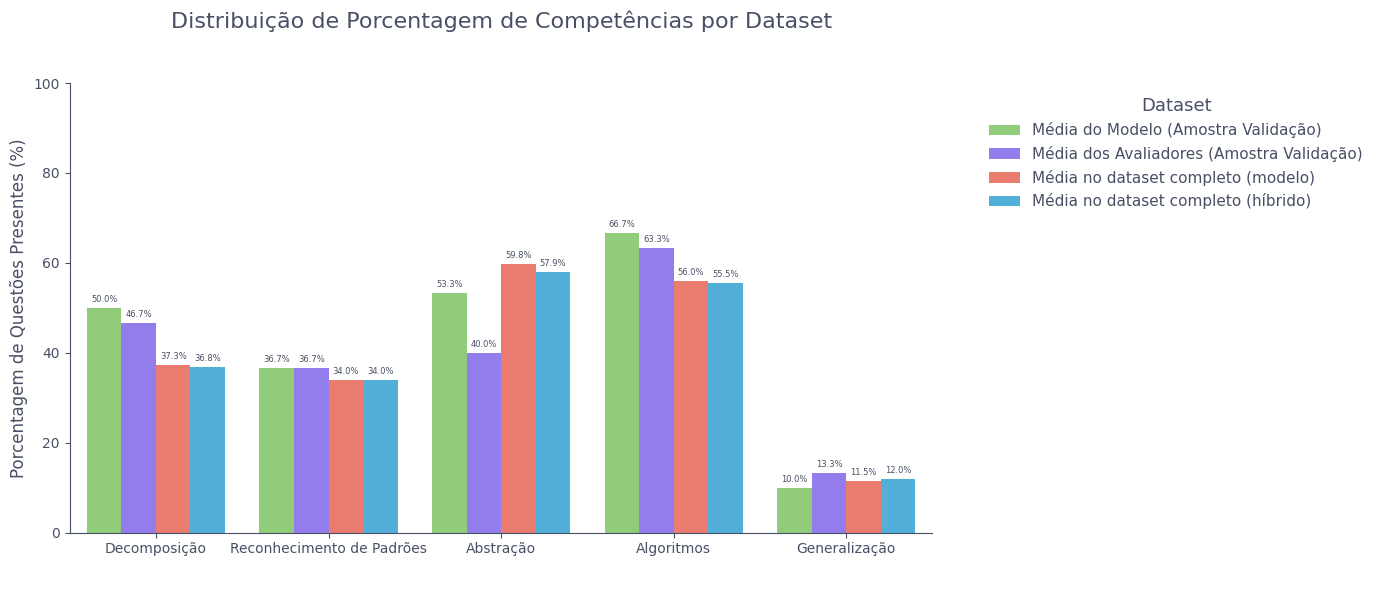

In [ ]:
plot_data = []

for comp in possible_competencies:
    competency_display_name = DEFINICOES[comp]['nome']

    its_col = f'its_{comp}'
    if its_col in validacao_df.columns:
        percentage_present = validacao_df[its_col].value_counts(normalize=True).get(True, 0) * 100
        plot_data.append({
            'Competência': competency_display_name,
            'Dataset': 'Média do Modelo (Amostra Validação)',
            'Porcentagem Presente': percentage_present
        })
    else:
        print(f"Warning: Coluna '{its_col}' não encontrada em validacao_df.")

    avs_col = f'avs_{comp}'
    if avs_col in validacao_df.columns:
        percentage_present = validacao_df[avs_col].value_counts(normalize=True).get(True, 0) * 100
        plot_data.append({
            'Competência': competency_display_name,
            'Dataset': 'Média dos Avaliadores (Amostra Validação)',
            'Porcentagem Presente': percentage_present
        })
    else:
        print(f"Warning: Coluna '{avs_col}' não encontrada em validacao_df.")

    if comp in df_completo.columns:
        percentage_present = df_completo[comp].value_counts(normalize=True).get(True, 0) * 100
        plot_data.append({
            'Competência': competency_display_name,
            'Dataset': 'Média no dataset completo (modelo)',
            'Porcentagem Presente': percentage_present
        })
    else:
        print(f"Warning: Coluna '{comp}' não encontrada em df_completo.")

    if comp in df_hibrido.columns:
        percentage_present = df_hibrido[comp].value_counts(normalize=True).get(True, 0) * 100
        plot_data.append({
            'Competência': competency_display_name,
            'Dataset': 'Média no dataset completo (híbrido)',
            'Porcentagem Presente': percentage_present
        })
    else:
        print(f"Warning: Coluna '{comp}' não encontrada em df_hibrido.")

plot_df = pd.DataFrame(plot_data)

if plot_df.empty:
    print("Nenhum dado disponível para plotar. Verifique os dataframes e os nomes das colunas.")
else:
    hex_codes = {
        "green": "#C7D9B7",
        "green_2": "#6B8851",
        "green_3": "#A4DB77",
        "red": "#CF8E93",
        "red_2": "#8C5257",
        "red_3": "#BB4C55",
        "gray": "#485065"
    }

    dataset_palette = {
        'Média do Modelo (Amostra Validação)': '#8ADA6C',
        'Média dos Avaliadores (Amostra Validação)': '#886BFF',
        'Média no dataset completo (modelo)': '#FF6D5A',
        'Média no dataset completo (híbrido)': '#3AB7F0'
    }

    plt.rcParams['text.color'] = hex_codes["gray"]
    plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
    plt.rcParams['xtick.color'] = hex_codes["gray"]
    plt.rcParams['ytick.color'] = hex_codes["gray"]

    plt.figure(figsize=(14, 6))
    ax = plt.gca()

    sns.barplot(x='Competência', y='Porcentagem Presente', hue='Dataset', data=plot_df, palette=dataset_palette, ax=ax)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(hex_codes["gray"])
    ax.spines['bottom'].set_color(hex_codes["gray"])

    plt.title('Distribuição de Porcentagem de Competências por Dataset', fontsize=16, color=hex_codes["gray"], pad=40)
    plt.xlabel(' ', fontsize=12, color=hex_codes["gray"])
    plt.ylabel('Porcentagem de Questões Presentes (%)', fontsize=12, color=hex_codes["gray"])
    plt.ylim(0, 100)
    plt.xticks(color=hex_codes["gray"])
    plt.yticks(color=hex_codes["gray"])

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=6, color=hex_codes["gray"])

    ax.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, title_fontsize='13', fontsize='11')
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

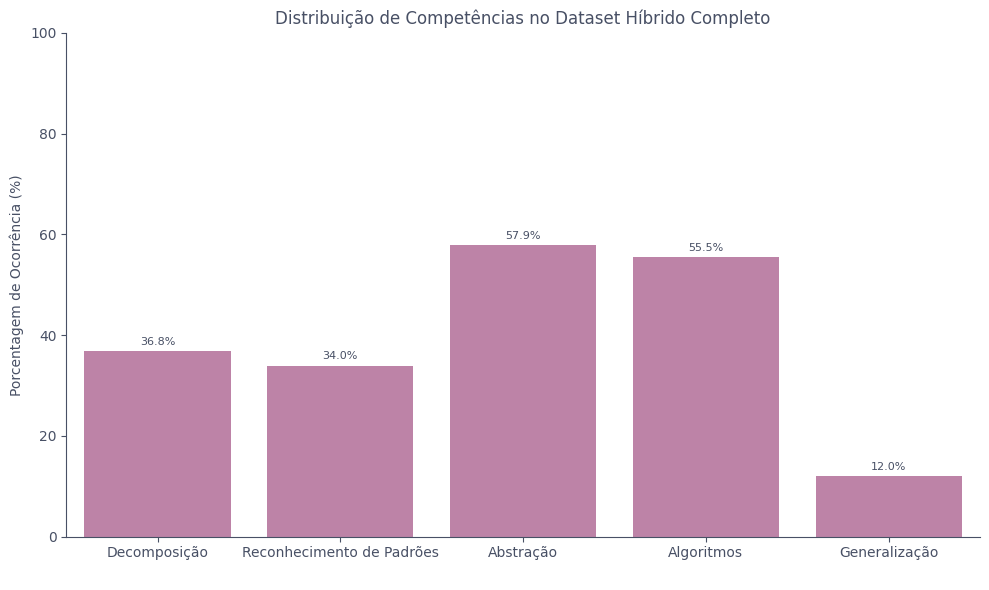

In [ ]:
plot_data = []

for comp in possible_competencies:
    competency_display_name = DEFINICOES[comp]['nome']
    if comp in df_hibrido.columns:
        percentage_present = df_hibrido[comp].value_counts(normalize=True).get(True, 0) * 100
        plot_data.append({
            'Competência': competency_display_name,
            'Dataset': 'Dataset Híbrido Completo',
            'Porcentagem Presente': percentage_present
        })

plot_df_manual = pd.DataFrame(plot_data)

hex_codes = {
    "gray": "#485065",
    "barras": "#C779AA",
}

plt.rcParams['text.color'] = hex_codes["gray"]
plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
plt.rcParams['xtick.color'] = hex_codes["gray"]
plt.rcParams['ytick.color'] = hex_codes["gray"]

plt.figure(figsize=(10, 6))
ax = plt.gca()

sns.barplot(x='Competência', y='Porcentagem Presente', data=plot_df_manual, color=hex_codes["barras"], ax=ax)

ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
ax.spines['left'].set_color(hex_codes["gray"]);
ax.spines['bottom'].set_color(hex_codes["gray"]);

plt.xlabel(' ', color=hex_codes["gray"])
plt.ylabel('Porcentagem de Ocorrência (%)', color=hex_codes["gray"])
plt.title('Distribuição de Competências no Dataset Híbrido Completo', color=hex_codes["gray"])
plt.ylim(0, 100)

plt.yticks(color=hex_codes["gray"])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=8, color=hex_codes["gray"])

plt.tight_layout()
plt.show()

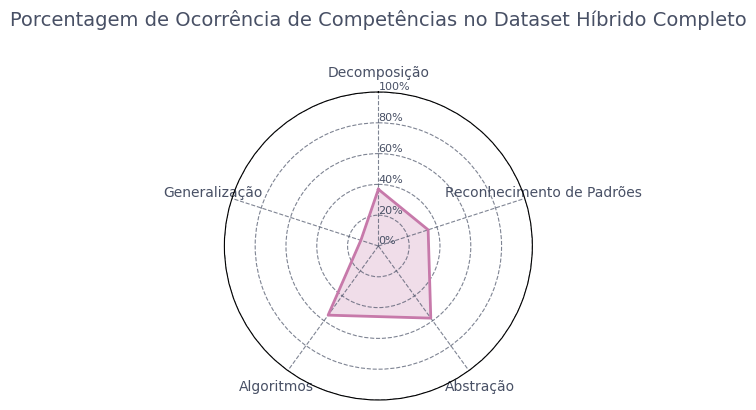

In [ ]:
categories = [DEFINICOES[comp]['nome'] for comp in possible_competencies]
N = len(categories)

percentages = []
for comp in possible_competencies:
    if comp in df_hibrido.columns:
        percentage_present = df_hibrido[comp].value_counts(normalize=True).get(True, 0) * 100
        percentages.append(percentage_present)
    else:
        percentages.append(0)

percentages = percentages + percentages[:1]
categories = categories + categories[:1]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles = angles + angles[:1]

hex_codes = {
    "gray": "#485065",
    "radar_fill": "#C779AA"
}

plt.rcParams['text.color'] = hex_codes["gray"]
plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
plt.rcParams['xtick.color'] = hex_codes["gray"]
plt.rcParams['ytick.color'] = hex_codes["gray"]

fig, ax = plt.subplots(figsize=(24, 4), subplot_kw=dict(polar=True))

ax.plot(angles, percentages, color=hex_codes["radar_fill"], linewidth=2, linestyle='solid')
ax.fill(angles, percentages, color=hex_codes["radar_fill"], alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories[:-1], color=hex_codes["gray"], size=10)

ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([f"{y}%" for y in np.arange(0, 101, 20)], color=hex_codes["gray"], size=8)
ax.set_ylim(0, 100)

ax.grid(True, linestyle='--', alpha=0.7, color=hex_codes["gray"])

plt.title('Porcentagem de Ocorrência de Competências no Dataset Híbrido Completo',
          size=14, color=hex_codes["gray"], y=1.08, pad=30)

plt.show()

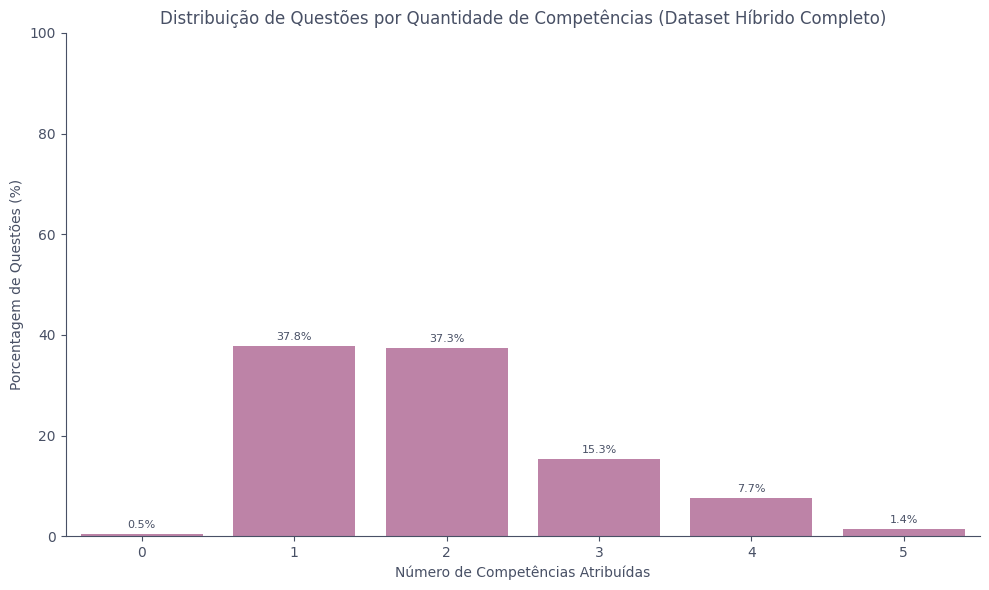

In [ ]:
distribution_hibrido = competency_counts_hibrido.value_counts(normalize=True).sort_index()

plot_df_distribution = pd.DataFrame({
    'Número de Competências': distribution_hibrido.index,
    'Porcentagem': distribution_hibrido.values * 100
})

hex_codes = {
    "gray": "#485065",
    "barras": "#C779AA"
}

plt.rcParams['text.color'] = hex_codes["gray"]
plt.rcParams['axes.labelcolor'] = hex_codes["gray"]
plt.rcParams['xtick.color'] = hex_codes["gray"]
plt.rcParams['ytick.color'] = hex_codes["gray"]

plt.figure(figsize=(10, 6))
ax = plt.gca()

sns.barplot(x='Número de Competências', y='Porcentagem', data=plot_df_distribution, color=hex_codes["barras"], ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(hex_codes["gray"])
ax.spines['bottom'].set_color(hex_codes["gray"])

plt.xlabel('Número de Competências Atribuídas', color=hex_codes["gray"])
plt.ylabel('Porcentagem de Questões (%)', color=hex_codes["gray"])
plt.title('Distribuição de Questões por Quantidade de Competências (Dataset Híbrido Completo)', color=hex_codes["gray"])
plt.ylim(0, 100)

plt.xticks(color=hex_codes["gray"])
plt.yticks(color=hex_codes["gray"])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=8, color=hex_codes["gray"])

plt.tight_layout()
plt.show()

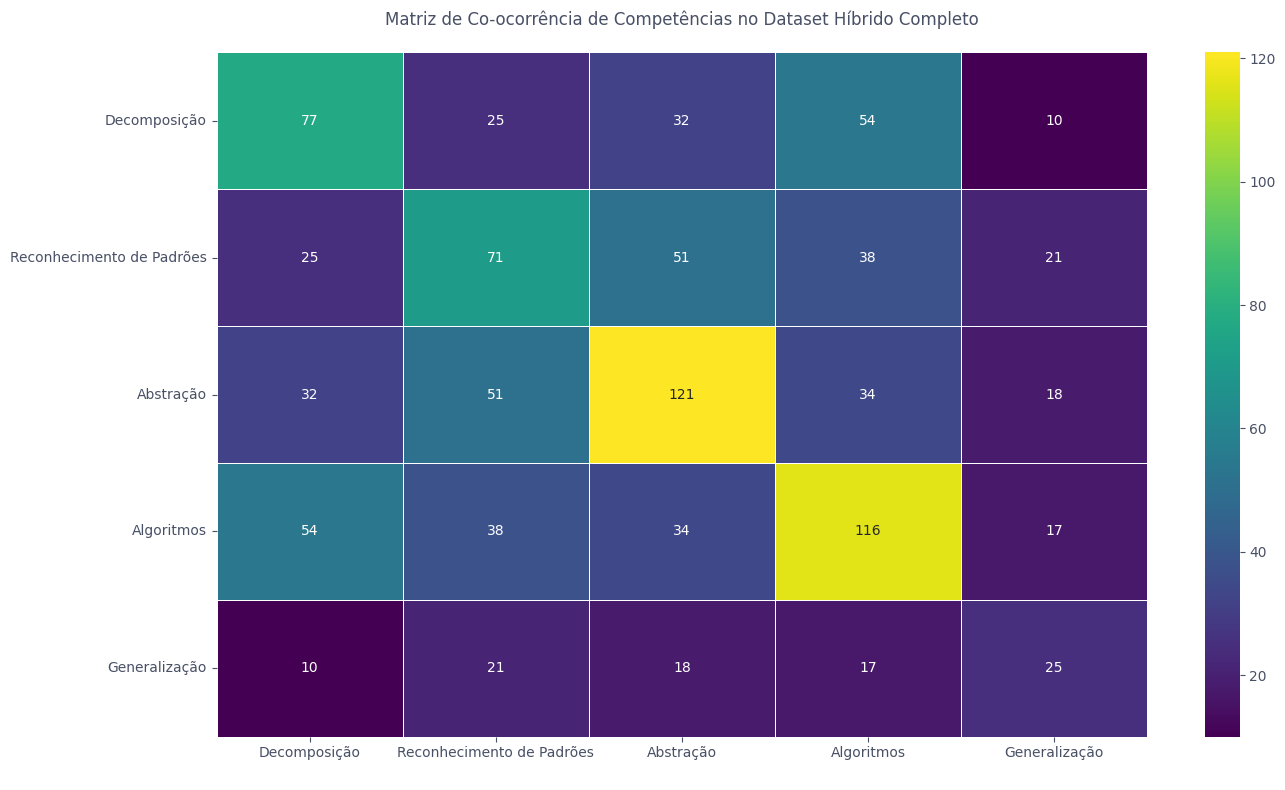

In [ ]:
competency_names = [DEFINICOES[comp]['nome'] for comp in possible_competencies]
co_occurrence_matrix = pd.DataFrame(0, index=competency_names, columns=competency_names)

for i, comp1 in enumerate(possible_competencies):
    for j, comp2 in enumerate(possible_competencies):
        if i <= j:
            count = df_hibrido[(df_hibrido[comp1] == True) & (df_hibrido[comp2] == True)].shape[0]
            co_occurrence_matrix.loc[DEFINICOES[comp1]['nome'], DEFINICOES[comp2]['nome']] = count
            if i != j:
                co_occurrence_matrix.loc[DEFINICOES[comp2]['nome'], DEFINICOES[comp1]['nome']] = count

plt.figure(figsize=(14, 8))
sns.heatmap(co_occurrence_matrix, annot=True, fmt="d", cmap="viridis", linewidths=.5)
plt.title('Matriz de Co-ocorrência de Competências no Dataset Híbrido Completo', pad=20)
plt.xlabel(' ')
plt.xticks(rotation=0, ha='center')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Demonstração do classificador

Esta seção visa executar o classificador em uma demo rápida, onde os espectadores podem sugerir enunciados ou classificar uma questão aleatória do dataset do POSCOMP.

Sugere-se que os espectadores tentem classificar manualmente antes de rodar a classificação automática, para que seja possível atestar se há concordância ou não entre humano e LLM em cenários reais.

## Instruções para carregar e preparar os dados

1.   Carregue o arquivo "dataset_qps_hibrido.csv" ou qualquer outro dataset de sua escolha e o renomeie para "dataset.csv"
2.   Rode da seção "Instalação de dependências" até a seção "Funções de comportamento do modelo"
3.   Rode o restante desta seção, então passe para a seção "Código para a demo" abaixo

Nesta seção, verificamos se o dataset foi carregado corretamente. Então, geramos o prompt para todos os enunciados, a fim de que a demo seja bem-sucedida.

É possível carregar outros datasets além do poscomp, desde que sua estrutura seja compatível com as colunas que são trabalhadas no classificador.

In [25]:
!wget -q -O dataset.csv 'https://raw.githubusercontent.com/EmiChristie/classificadores-pensamento-computacional/refs/heads/main/data/modified%20data/classificador_competencias/dataset_questoes_problema/dataset_qps_hibrido.csv'
qps = pd.read_csv('dataset.csv')

In [26]:
qps['prompt'] = qps.apply(gerar_prompt, axis = 1)

In [27]:
qps.head(1)

,id,edicao,numero,enunciado,alternativas,area_conhecimento,area,subarea,gabarito,atributo_rag,ehQuestaoProblema,prompt
0,2002-30,2002,30,Considere um problema em que são dados 5 objet...,"['a) 12.2', 'b) 21.5', 'c) 30.34', 'd) 38.83',...",Fundamentos da Computação,Algoritmos e Estrutura de Dados,Técnicas de Projeto de Algoritmos: Método da F...,D,fundamentos da computacao - algoritmos e estru...,True,\nQUESTÃO:\nConsidere um problema em que são d...


Em seguida, adaptamos a função "recupera_resposta" para que sua saída seja mais legível.

In [ ]:
def recupera_resposta_demo(enunciado_questao):
  obj = get_completion(enunciado_questao, "gpt-5.4", SYSTEM_PROMPT)
  model_response_content = obj.choices[0].message.content.strip()

  try:
    identified_competency_ids = ast.literal_eval(model_response_content)

    if isinstance(identified_competency_ids, list) and all(isinstance(x, int) for x in identified_competency_ids):
      identified_competency_names = []
      for comp_id in identified_competency_ids:
        if 0 <= comp_id < len(possible_competencies):
          competency_key = possible_competencies[comp_id]
          identified_competency_names.append(DEFINICOES[competency_key]['nome'])

      if identified_competency_names:
        return ", ".join(identified_competency_names)
      else:
        return "Nenhuma competência identificada."
    else:
      return "Não foi possível classificar a questão (formato inesperado)."
  except (ValueError, SyntaxError):
    return "Não foi possível classificar a questão (erro ao analisar a resposta do modelo)."


## Código para a demo

Para fins de uma demonstração rápida do classificador, é possível escolher uma questão aleatória do dataset do poscomp, ou inserir um enunciado novo.

In [ ]:
import random

In [ ]:
n_questao = random.randint(0, 208) #um número entre 0 e 208, correspondendo a todas as questões-problema do dataset do POSCOMP
questao = qps.iloc[n_questao]

Comente a linha ```enunciado_questao = questao["prompt"]```
para que o enunciado personalizado seja utilizado!

In [ ]:
enunciado_questao = """
QUESTÃO:

Insira sua questão aqui.
"""

enunciado_questao = questao["prompt"]

In [ ]:
print(enunciado_questao)


QUESTÃO:
Considere as tabelas, a seguir, criadas em um banco de dados relacional através da linguagem SQL.

```
CREATE TABLE Empregado
( ecod int PRIMARY KEY,
  nome varchar (32),
  salario number (7,2),
  dcod int FOREIGN KEY REFERENCES Departamento (dcod));
CREATE TABLE Departamento
( dcod int PRIMARY KEY,
  dnome varchar (12),
  chefe int FOREIGN KEY REFERENCES Empregado (ecod));
```

Sejam as consultas (C1, C2 e C3) também em SQL, a seguir.
```
C1. SELECT nome, salario FROM Empregado E, Departamento D
      WHERE E.dcod = D.dcod AND E.ecod = D.chefe;
C2. SELECT nome, salario FROM Empregado as E INNER JOIN Departamento as D
      ON E.dcod=D.dcod WHERE E.ecod = D.chefe;
C3. SELECT nome, salario FROM E.ecod = D.chefe;
```
Com relação às consultas, assinale a alternativa correta.



Antes de executar a célula abaixo, convide seu público a pensar sobre a natureza da questão. Que competências são evocadas pela questão?

Depois, confira se o julgamento do classificador concorda com o julgamento humano.

In [ ]:
print(recupera_resposta_demo(enunciado_questao))

Reconhecimento de Padrões, Abstração
